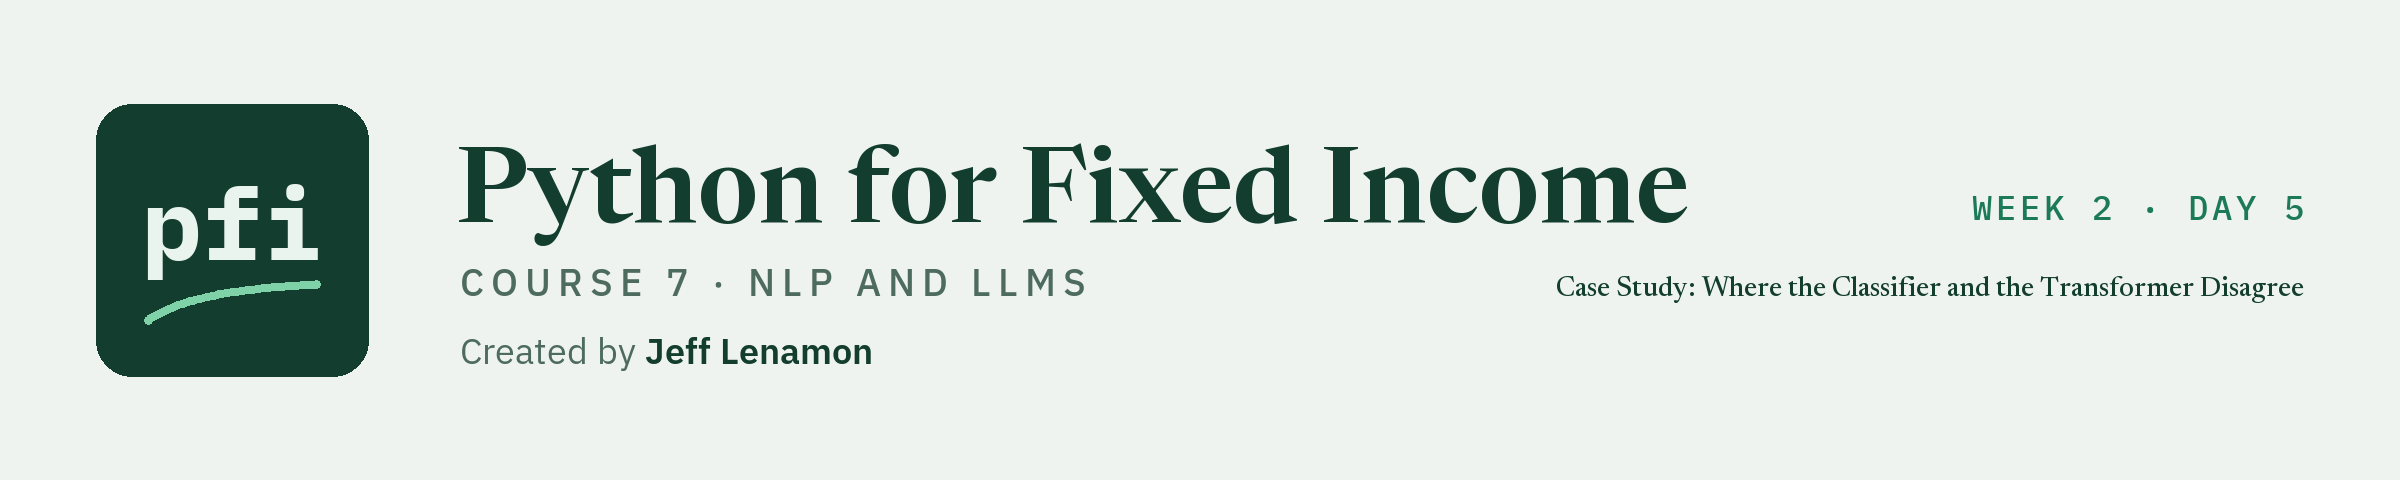

# Case Study: Where the Classifier and the Transformer Disagree

Week 2, Day 5. Today you read where three 8-K item models assign different items, then open the 2025 test sections once and compare the three models on them, with an interval on each difference.

**Data:** `course7_8k_items.csv`, 5,126 item sections of Form 8-K current reports filed on EDGAR, 2019 to 2025, each labelled by the item its filer chose: **real**, public records (sec.gov), a sample drawn by the course (DATA.md).

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course7_nlp_and_llms/week2/day5/10_case_study_where_the_classifier_and_the_transformer_disagree.ipynb)

**Data:** `course7_8k_zero_shot.csv` and `course7_8k_minilm.npy`: the course's two pinned models' outputs on the 8-K sections, computed once by the course's tool on one thread: **the course's own derived data** (DATA.md), checked live on a sample of the test sections in this notebook.

Days 3 and 7 chose three models for the 8-K items on the 2024 validation sections: day 3's TF-IDF classifier with balanced class weights, day 7's zero-shot model, and day 7's logistic regression on sentence embeddings. Each assigns an item to every section, and they often assign different ones. Today first reads where they part, section by section, on the validation rows: which words each model had to go on. Then the case study opens the 2025 test sections, once, and compares the three models on them.

**The rules for real documents, as on every day of this course.**

* **The documents are real.** Each section is the text of a Form 8-K that its company filed on EDGAR, a public record, quoted exactly as filed (cut at 300 words by the course's tool), with a source line under every excerpt.
* **The labels are the filers' own.** A section's item is the heading its filer chose. A model's output is "the item the model assigns" or "the model's score for Item 2.04", and the true label is "the filer's item". It is never a default signal, never a distress flag or a warning, and never a credit event or a view on the company.
* **Issuer names appear only as the authors of the documents being read**, in the source line. No table in this notebook lists companies. The Item 5.02 sections, which name officers and directors, are counted by item only: no text from them is printed, and no disagreement that involves Item 5.02 is read.

**Rows.** Every model on the 8-K sections in this notebook is fitted on the sections filed from 2019 to 2023 and chosen on the sections filed in 2024; the 735 sections filed in 2025 are opened once, in section 10.6, for the models chosen before it.

Today you will:

1. Rebuild the three models as chosen on validation, and add `disagreements` to `textkit`.
2. Read ten disagreements with their source lines, and the words each model had to go on.
3. Open the 2025 test sections once: check a live sample against the committed outputs, then score the three models.
4. Put a paired bootstrap interval on each difference in macro F1, log the test rows once, and write a three-sheet workbook.
5. Say what the comparison shows, and where it fails.

Q. Set up today's work folder: the thread settings, the quiet-loading settings, PyTorch on one thread, the seed, the modules, and today's three data files.

In [1]:
# today's setup: thread settings, quiet model loading, the modules, the seed, the course data, a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, or PyTorch is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# the model libraries print download bars and notices; these lines must run before they are imported
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("torch", "torch"), ("transformers", "transformers"), ("sentence_transformers", "sentence-transformers"), ("openai", "openai"), ("pydantic", "pydantic"), ("bs4", "beautifulsoup4"), ("pypdf", "pypdf"), ("pypdfium2", "pypdfium2"), ("dotenv", "python-dotenv"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd
import torch

# one thread for PyTorch too, set before it runs anything
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

# the versions the saved outputs of this notebook came from (course7_nlp_and_llms/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "torch": "2.14.1", "transformers": "5.19.0", "sentence-transformers": "6.1.0", "openai": "3.26.0", "pydantic": "2.13.5", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name].split("+")[0] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42
# PyTorch's own generator; a pretrained model in evaluation mode draws no random number, but the seed costs nothing
torch.manual_seed(SEED)

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "course7_fomc_statements.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course7_10_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["course7_8k_items.csv", "course7_8k_zero_shot.csv", "course7_8k_minilm.npy"]
for name in DATA_FILES:
    (work / name).parent.mkdir(parents=True, exist_ok=True)
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, torch 2.14.1, transformers 5.19.0, sentence-transformers 6.1.0, openai 3.26.0, pydantic 2.13.5, pytest 9.1.1
Work folder: pfi_course7_10_srkm7py4, in your temp folder
Data files from the data folder of the course repo: course7_8k_items.csv, course7_8k_zero_shot.csv, course7_8k_minilm.npy
SEED = 42


* The setup cell in its model-day form, as on day 6 (day 6 explains the PyTorch lines; day 1 explains the rest). Today's three data files are the 8-K sections and day 7's two committed model outputs.

Q. Write the earlier courses' modules today needs, unchanged: `mlkit.py`, `ensemblekit.py`.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)


def bootstrap_interval(y_true, proba, metric, n_boot: int = 1000, level: float = 0.95,
                       seed: int = 42) -> tuple[float, float]:
    """A percentile interval for a metric, from resampling the scored rows.

    Inputs: y_true, the outcomes of the scored rows (0 or 1); proba, the model's outputs on them; metric, a
    function metric(y_true, proba) such as roc_auc_score; n_boot, how many resamples; level, the interval's
    coverage (0.95 for a 95 percent interval); seed, the resampling seed.
    Output: (lower, upper), numpy.percentile (linear) of the n_boot values at (1 - level) / 2 and (1 + level) / 2.
    Convention: each resample draws len(y_true) rows with replacement by np.random.default_rng(seed); a resample
    holding one class only is drawn again. The interval describes the noise from which rows happened to be
    scored, not the noise from refitting the model.
    Excel: =PERCENTILE.INC(range,0.025) and =PERCENTILE.INC(range,0.975) on the pasted resampled values.
    Raises ValueError on inputs of different lengths, fewer than both classes, n_boot below 1, or level outside
    (0, 1).
    """
    actual, scores = np.asarray(y_true), np.asarray(proba, dtype=float)
    if actual.size == 0 or actual.shape != scores.shape:
        raise ValueError(f"y_true and proba must be non-empty and the same length, not {actual.size} and {scores.size}")
    if len(np.unique(actual)) < 2:
        raise ValueError("y_true must hold both classes")
    if n_boot < 1 or not 0 < level < 1:
        raise ValueError(f"n_boot must be at least 1 and level between 0 and 1, not {n_boot}, {level}")
    rng = np.random.default_rng(seed)
    values = []
    while len(values) < n_boot:
        rows = rng.integers(0, actual.size, actual.size)
        # a resample with one class has no ROC AUC; draw again
        if len(np.unique(actual[rows])) < 2:
            continue
        values.append(metric(actual[rows], scores[rows]))
    lower, upper = np.percentile(values, [100 * (1 - level) / 2, 100 * (1 + level) / 2])
    return float(lower), float(upper)


from sklearn.model_selection import cross_val_score  # one score per fold


def course4_polish_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish bankruptcy file, without its 1,170 test rows.

    Input: frame, the 5,910 rows of polish_bankruptcy_5year.csv read with float_precision="round_trip".
    Output: X_train (Attr1 to Attr64, missing values kept) and y_train (class), 4,680 rows, 326 of them bankrupt,
    with the file's row labels. Course 4's 1,170 test rows are never returned.
    Convention: Course 4's capstone steps: exact duplicate rows dropped (5,910 to 5,850), then
    train_test_split(test_size=0.2, stratify=y, random_state=42).
    Raises ValueError if the frame does not hold 5,910 rows with a class column.
    """
    if len(frame) != 5_910 or "class" not in frame.columns:
        raise ValueError(f"frame must be the 5,910 rows of the Polish file with a class column, not {len(frame)} rows")
    unique = frame.drop_duplicates()
    X, y = unique.drop(columns="class"), unique["class"]
    # Course 4's split: the second part was its test set, dropped here
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_train, y_train


def nested_score(search, X, y, outer=None, scoring: str = "average_precision") -> pd.Series:
    """An honest score for a tuned model: the whole search is repeated inside each outer fold.

    Inputs: search, an unfitted RandomizedSearchCV or GridSearchCV that carries its own inner cv; X, y, the
    training rows; outer, the outer splitter (default mlkit.cv_folds()); scoring, the metric.
    Output: one score per outer fold, indexed fold_1, fold_2, ...: each fold's search tunes on the other folds
    only and is scored on its own held-out rows (cross_val_score, n_jobs=1).
    Convention: a search's best_score_ is the best of many noisy numbers and is not an honest score of the model it
    chose; the mean of this Series is.
    Raises ValueError if the search has no inner cv.
    """
    if getattr(search, "cv", None) is None:
        raise ValueError("give the search its own inner cv, for example StratifiedKFold(3, shuffle=True, random_state=42)")
    folds = outer if outer is not None else mlkit.cv_folds()
    scores = cross_val_score(search, X, y, cv=folds, scoring=scoring, n_jobs=1)
    return pd.Series(scores, index=[f"fold_{i}" for i in range(1, len(scores) + 1)], name=scoring)


def search_table(search, top: int = 5) -> pd.DataFrame:
    """A fitted search's results as a short table, best first.

    Inputs: search, a fitted RandomizedSearchCV or GridSearchCV; top, how many candidates to keep.
    Output: columns rank, mean, sd (the mean and standard deviation of the fold scores, ddof=0, as cv_results_),
    then one column per searched parameter (the param_ prefix dropped), sorted by rank.
    Excel: =AVERAGE and =STDEV.P of a candidate's five fold scores give its mean and sd (STDEV.S does not).
    Raises ValueError if the search is not fitted.
    """
    if not hasattr(search, "cv_results_"):
        raise ValueError("the search is not fitted: call fit first")
    results = pd.DataFrame(search.cv_results_)
    params = [name for name in results.columns if name.startswith("param_")]
    table = results[["rank_test_score", "mean_test_score", "std_test_score"] + params]
    table.columns = ["rank", "mean", "sd"] + [name[len("param_"):] for name in params]
    return table.sort_values("rank", kind="stable").head(top).reset_index(drop=True)


from sklearn.base import BaseEstimator, TransformerMixin  # what makes a class a scikit-learn transformer
from sklearn.utils.validation import check_is_fitted  # stops a transformer used before fit


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """A ratio of two columns that is never infinite: missing where the denominator is 0 or either side is missing.

    Inputs: numerator, denominator, two Series with the same row labels.
    Output: numerator / denominator as floats, with NaN where the denominator is 0 or either value is missing.
    Convention: a model that handles missing values (or an imputer inside a pipeline) then deals with those rows;
    an infinity would break most estimators.
    Excel: =IF(OR(B2=0,B2="",A2=""),NA(),A2/B2), where =A2/B2 alone gives #DIV/0!.
    Raises ValueError if the two Series do not have the same row labels.
    """
    if not numerator.index.equals(denominator.index):
        raise ValueError("numerator and denominator must have the same row labels")
    defined = denominator.ne(0) & numerator.notna() & denominator.notna()
    # divide only where the ratio is defined; every other row stays NaN
    return numerator.astype(float).div(denominator.astype(float).where(defined)).where(defined)


class ClipToTraining(TransformerMixin, BaseEstimator):
    """Clip each column to bounds learned from the rows it is fitted on (by default the 1st and 99th percentiles).

    Inside a pipeline, fit sees only each fold's training rows, so the bounds never come from held-out rows.
    Parameters: lower, upper, the quantiles (0 <= lower < upper <= 1).
    Fitted attributes: lower_, upper_, one bound per column (numpy.nanquantile, linear, missing values ignored);
    n_features_in_; feature_names_in_ when fitted on a DataFrame.
    transform returns a float array; a missing value stays missing.
    Excel: =PERCENTILE.INC(training_range,0.01) and 0.99 give the bounds; =MIN(MAX(x,low),high) clips.
    """

    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(f"need 0 <= lower < upper <= 1, not {self.lower}, {self.upper}")
        values = np.asarray(X, dtype=float)
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = values.shape[1]
        # each column's bounds, from these rows only
        self.lower_ = np.nanquantile(values, self.lower, axis=0)
        self.upper_ = np.nanquantile(values, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["lower_", "upper_"])
        values = np.asarray(X, dtype=float)
        if values.shape[1] != self.n_features_in_:
            raise ValueError(f"X has {values.shape[1]} columns, the transformer was fitted on {self.n_features_in_}")
        return np.clip(values, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["lower_", "upper_"])
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)


def class_counts_after(sampler, X, y) -> pd.Series:
    """How many rows of each class a resampler leaves: for showing what a sampler does.

    Inputs: sampler, an imbalanced-learn sampler such as SMOTE(random_state=42); X, y, rows with no missing value.
    Output: the count of each class after sampler.fit_resample(X, y), indexed by class.
    Convention: a demonstration only. Rows a model is scored on are never resampled; resampling belongs inside an
    imblearn pipeline, where cross-validation resamples each fold's training rows only.
    """
    _, y_resampled = sampler.fit_resample(X, y)
    return pd.Series(y_resampled).value_counts().sort_index()


def prior_correction(score, fitted_rate: float, true_rate: float) -> np.ndarray:
    """Move a score from a model fitted at one outcome rate back to the rate of the real rows.

    Inputs: score, the model's outputs (between 0 and 1); fitted_rate, the outcome rate of the rows the model was
    fitted on (0.5 after SMOTE to balance); true_rate, the outcome rate of the real training rows.
    Output: each score's odds multiplied by k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate)),
    turned back into a number between 0 and 1: s * k / (s * k + 1 - s).
    Convention: a closed form that assumes resampling changed only the class shares; it leaves the ranking of rows
    unchanged. Equal rates give the score back.
    Excel: k in one cell, =(t/(1-t))/(f/(1-f)), then =p*k/(p*k+1-p) filled down.
    Raises ValueError if a rate is not strictly between 0 and 1 or a score is outside [0, 1].
    """
    for name, rate in (("fitted_rate", fitted_rate), ("true_rate", true_rate)):
        if not 0 < rate < 1:
            raise ValueError(f"{name} must be strictly between 0 and 1, not {rate}")
    s = np.asarray(score, dtype=float)
    if s.size == 0 or (s < 0).any() or (s > 1).any():
        raise ValueError("score must be non-empty and between 0 and 1")
    # the factor that moves odds from the fitted rate to the true rate
    k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate))
    return s * k / (s * k + 1 - s)


import re  # whole-word search

# words that turn a description of a model into a claim about causes; a reminder, not a proof
EXPLANATION_WORDS = ["cause", "causes", "caused", "driver", "drivers", "drives", "reason", "reasons", "because"]


def shap_table(shap_values, top: int | None = None) -> pd.DataFrame:
    """Mean absolute SHAP value per feature, largest first.

    Inputs: shap_values, a shap.Explanation for one output (rows by features), for example
    shap.TreeExplainer(model)(X); top, how many features to keep (all if None).
    Output: a DataFrame indexed by feature with columns mean_abs_shap (the average size of the feature's
    contribution to the model's log-odds, in log-odds) and rank (1 = largest).
    Convention: a SHAP value describes how the model's output for a row splits across features; it is not the
    effect of changing a feature and not a cause.
    Excel: =AVERAGE(ABS(column)) on a pasted column of SHAP values.
    Raises ValueError if the values are not one row per observation and one column per feature.
    """
    values = np.asarray(shap_values.values, dtype=float)
    if values.ndim != 2 or values.shape[1] != len(shap_values.feature_names):
        raise ValueError(f"expected rows by features, got shape {values.shape}")
    table = pd.DataFrame({"mean_abs_shap": np.abs(values).mean(axis=0)},
                         index=pd.Index(shap_values.feature_names, name="feature"))
    table = table.sort_values("mean_abs_shap", ascending=False, kind="stable")
    table["rank"] = np.arange(1, len(table) + 1)
    return table if top is None else table.head(top)


def assert_additive(shap_values, raw_score, tol: float = 1e-9) -> None:
    """Stop unless each row's SHAP values add up to the model's raw output (log-odds).

    Inputs: shap_values, a shap.Explanation for one output; raw_score, the model's log-odds for the same rows
    (LightGBM: predict(X, raw_score=True); XGBoost: predict(X, output_margin=True)); tol, the largest gap allowed
    (1e-9 for LightGBM; 1e-5 for XGBoost, which computes in float32).
    Output: None when base value + the row's SHAP values equals raw_score in every row within tol.
    Convention: the contributions add up in log-odds, not in probability; mlkit.logistic_probability turns the sum
    into the model's probability.
    Raises AssertionError naming the largest gap and its row position, and ValueError on lengths that differ.
    """
    values = np.asarray(shap_values.values, dtype=float)
    raw = np.asarray(raw_score, dtype=float)
    if values.ndim != 2 or values.shape[0] != raw.size:
        raise ValueError(f"shap_values has {values.shape[0]} rows and raw_score {raw.size}")
    # base value plus the row's contributions, against the model's own log-odds
    gaps = np.abs(np.asarray(shap_values.base_values, dtype=float) + values.sum(axis=1) - raw)
    worst = int(np.argmax(gaps))
    if gaps[worst] > tol:
        raise AssertionError(f"SHAP values do not add up to raw_score: largest gap {gaps[worst]:.3g} at row "
                             f"position {worst} (tolerance {tol:g}); raw_score must be log-odds, not a probability")


def assert_described(text: str) -> None:
    """Stop if a written description uses a forecast word or a cause word.

    Input: text, a description of what a model shows.
    Output: None if the text passes mlkit.assert_descriptive and holds no word of EXPLANATION_WORDS as a whole word,
    in any case.
    Convention: the lists are a reminder, not a proof. "because" is on the list so the writer looks again at every
    causal sentence; a description that needs it rewrites the sentence.
    Raises ValueError naming the words found.
    """
    mlkit.assert_descriptive(text)
    found = [word for word in EXPLANATION_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses cause or explanation words: {found}")

Writing ensemblekit.py


Q. Write `textkit.py` and `test_textkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [4]:
%%writefile textkit.py
"""textkit: text as data for fixed income, from a regular expression to a checked LLM extraction.

Written day by day in Python for Fixed Income, Course 7: NLP and LLMs.

Conventions, the same in every function:
- Text is normalized by normalize_text before it is counted, searched, or compared: Unicode NFC, a fixed map of
  look-alike characters (no-break space, non-breaking hyphen, curly quotes, dashes), one space for every run of
  white space, and one newline between paragraphs. Source files keep the text exactly as published.
- A token is a run of lower-case letters and digits, joined by single hyphens, apostrophes, or full stops
  (TOKEN_PATTERN): "mortgage-backed" and "4.750" are one token each, "1/4" is two. No stemming.
- Section numbers and 8-K item codes are text ("4.12", "2.04"), so "4.10" never becomes 4.1.
- Money is in US dollars as whole numbers of dollars (855_000_000); percentages are as the source writes them
  (15.0 means 15.0 percent); ratios are floats with the unit "x" (2.0 means 2.00 to 1.00).
- The seed is 42 wherever a function takes one.
- Every output describes what a document says. Nothing here is a forecast, a rating, or a credit view.
- Empty inputs, or inputs of the wrong shape, raise ValueError with a message that says what was wrong.
"""
import re  # regular expressions
import unicodedata  # Unicode normalization

import pandas as pd  # tables with labels

import mlkit  # Course 4's module, unchanged: the split checks and the description check

# one token: letters and digits, joined by single hyphens, apostrophes, or full stops
TOKEN_PATTERN = r"[a-z0-9]+(?:[-'.][a-z0-9]+)*"
# a section heading at the start of a line: "Section 4.12. Limitation on Indebtedness" or "SECTION 4.12"; the
# title, if any, starts with a capital letter or "[", so a cross-reference that starts a line ("Section 4.12(b)",
# "Section 4.13 or Section 4.19 of the Indenture") is not a heading
SECTION_PATTERN = (r"^[ \t]*(?:SECTION|Section)[ \t]+(?P<number>\d{1,2}\.\d{1,2})(?![\d(])\.?"
                   r"(?:[ \t]+(?P<title>[A-Z\[][^\n]*?))?[ \t]*(?:\.(?=[ \t]|$)|$)")
# look-alike characters and the plain character each becomes (COURSE7_SPEC.md, "Conventions")
CHARACTER_MAP = {
    "\u00a0": " ",  # no-break space
    "\u2010": "-",  # hyphen
    "\u2011": "-",  # non-breaking hyphen
    "\u2013": "-",  # en dash
    "\u2014": "-",  # em dash
    "\u2018": "'",  # left single quote
    "\u2019": "'",  # right single quote
    "\u201c": '"',  # left double quote
    "\u201d": '"',  # right double quote
}


def normalize_text(text: str) -> str:
    """Return text with look-alike characters made plain and white space tidied.

    Input: text, any string.
    Output: the text after three steps: Unicode NFC; each character of CHARACTER_MAP replaced by its plain form;
    every run of white space that holds a line break becomes one newline (a paragraph break), and every other run
    of white space becomes one space; no space or newline at either end.
    Convention: idempotent, so normalize_text(normalize_text(t)) == normalize_text(t). Run it on both sides of any
    comparison of text.
    Raises ValueError if text is not a string.
    """
    if not isinstance(text, str):
        raise ValueError(f"text must be a string, not {type(text).__name__}")
    # one code point per accented letter, then the fixed map
    text = unicodedata.normalize("NFC", text).translate(str.maketrans(CHARACTER_MAP))
    # a run of white space with a line break in it is a paragraph break; any other run is one space
    text = re.sub(r"[^\S\n]*\n\s*", "\n", text)
    text = re.sub(r"[^\S\n]+", " ", text)
    return text.strip()


def tokenize(text: str, lower: bool = True) -> list[str]:
    """Split text into tokens with TOKEN_PATTERN, after normalize_text.

    Inputs: text; lower, True to lower-case first (the course's default; GloVe and TF-IDF are lower case).
    Output: the tokens in the order they appear. With lower=False the pattern runs ignoring case and each token
    keeps its case. A text with no letter or digit gives an empty list.
    Convention: "mortgage-backed", "longer-term", "4.750", and "company's" are one token each; "1/4" is two
    ("1", "4"), because a slash is not a joiner. No stop words are removed and no word is stemmed.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    if lower:
        return re.findall(TOKEN_PATTERN, text.lower())
    return re.findall(TOKEN_PATTERN, text, flags=re.IGNORECASE)


def find_sections(text: str, pattern: str = SECTION_PATTERN) -> pd.DataFrame:
    """Find the section headings of an indenture and where each section starts and ends.

    Inputs: text, the indenture after normalize_text (one paragraph per line); pattern, a regular expression run
    with re.MULTILINE that has the named groups number and title (title may be empty).
    Output: a DataFrame with one row per section, in the order of the text: number (text, "4.12"), title, start
    (the heading's first character), end (the next kept heading's start, or the end of the text).
    Convention: an indenture lists every section twice, once in the table of contents and once in the body, so for
    each number only the last heading is kept: the body's. A heading must start a line.
    Raises ValueError if no heading is found.
    """
    found = {}
    for match in re.finditer(pattern, text, flags=re.MULTILINE):
        # a later heading with the same number replaces an earlier one: the table of contents comes first
        found[match.group("number")] = (match.start(), (match.group("title") or "").strip())
    if not found:
        raise ValueError("no section heading found; check the pattern against one heading of the text")
    rows = sorted(((start, number, title) for number, (start, title) in found.items()))
    starts = [start for start, _, _ in rows] + [len(text)]
    return pd.DataFrame({"number": [number for _, number, _ in rows], "title": [title for _, _, title in rows],
                         "start": starts[:-1], "end": starts[1:]})


def defined_terms(text: str) -> pd.DataFrame:
    """Find every definition of the form "Term" means ... or "Term" has the meaning ...

    Input: text, for example Section 1.01 of an indenture; curly quotes are made straight by normalize_text first,
    so start values count characters of the normalized text.
    Output: a DataFrame with one row per definition, in the order of the text: term (without its quotes), start
    (the opening quote's position in the normalized text), kind ("means" or "has the meaning").
    Convention: a term starts with a capital letter or a digit. Duplicates are kept, so a term defined twice shows
    twice; count them with value_counts.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    pattern = r'"(?P<term>[A-Z0-9][^"\n]{0,100}?)"\s+(?P<kind>means|has the meaning)\b'
    rows = [{"term": m.group("term"), "start": m.start(), "kind": m.group("kind")}
            for m in re.finditer(pattern, text)]
    return pd.DataFrame(rows, columns=["term", "start", "kind"])


import numpy as np  # arrays, from day 2


def term_counts(docs: list[str], vocabulary: list[str] | None = None) -> pd.DataFrame:
    """Count each term in each document: the bag of words.

    Inputs: docs, a list of texts; vocabulary, the terms to count, in the order wanted (None counts every token
    found, with the columns sorted alphabetically).
    Output: a DataFrame of whole numbers, one row per document (in input order) and one column per term; a term
    missing from a document counts 0.
    Convention: tokens come from tokenize (lower case, TOKEN_PATTERN), so on plain ASCII text the table equals
    CountVectorizer(token_pattern=TOKEN_PATTERN) on the same vocabulary.
    Raises ValueError if docs is empty.
    """
    if len(docs) == 0:
        raise ValueError("docs is empty")
    tokens = [tokenize(doc) for doc in docs]
    columns = list(vocabulary) if vocabulary is not None else sorted({t for doc in tokens for t in doc})
    position = {term: j for j, term in enumerate(columns)}
    counts = np.zeros((len(docs), len(columns)), dtype=np.int64)
    for i, doc in enumerate(tokens):
        for token in doc:
            if token in position:
                counts[i, position[token]] += 1
    return pd.DataFrame(counts, columns=columns)


def idf(doc_freq, n_docs: int) -> np.ndarray:
    """Inverse document frequency with scikit-learn's smoothing: ln((1 + n) / (1 + df)) + 1.

    Inputs: doc_freq, the number of documents each term appears in (an array of whole numbers); n_docs, the number
    of documents.
    Output: a float64 array, one weight per term. A term in every document gets 1.0, never 0; a rarer term gets
    more.
    Convention: equal to TfidfVectorizer(smooth_idf=True).idf_ (the default). The log is natural.
    Raises ValueError if doc_freq is empty, any df is below 0 or above n_docs, or n_docs is below 1.
    """
    df = np.asarray(doc_freq, dtype=np.float64)
    if df.size == 0 or n_docs < 1:
        raise ValueError("doc_freq must hold at least one term and n_docs must be at least 1")
    if (df < 0).any() or (df > n_docs).any():
        raise ValueError(f"every document frequency must be between 0 and n_docs ({n_docs})")
    return np.log((1.0 + n_docs) / (1.0 + df)) + 1.0


def tfidf_by_hand(counts, sublinear: bool = False) -> np.ndarray:
    """TF-IDF from a table of raw counts, each row scaled to length 1.

    Inputs: counts, documents by terms (an array or a DataFrame from term_counts); sublinear, True to use
    1 + ln(tf) in place of tf for every count above 0 (scikit-learn's sublinear_tf).
    Output: a float64 array of the same shape: term frequency times idf, then each row divided by its Euclidean
    length. A document with no counted term stays a row of zeros.
    Convention: equal to TfidfVectorizer on the same vocabulary within 1e-12 (smooth idf, l2 norm).
    Raises ValueError if counts is not two-dimensional or holds a negative count.
    """
    tf = np.asarray(counts, dtype=np.float64)
    if tf.ndim != 2 or tf.size == 0:
        raise ValueError("counts must be a non-empty table of documents by terms")
    if (tf < 0).any():
        raise ValueError("counts must not be negative")
    weights = idf((tf > 0).sum(axis=0), tf.shape[0])
    if sublinear:
        tf = np.where(tf > 0, 1.0 + np.log(np.where(tf > 0, tf, 1.0)), 0.0)
    matrix = tf * weights
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    # a zero row has length 0: divide by 1 instead, so it stays zero rather than becoming NaN
    return matrix / np.where(norms == 0, 1.0, norms)


def cosine_similarity_matrix(A, B=None) -> np.ndarray:
    """Cosine similarity of every row of A with every row of B (or of A with itself).

    Inputs: A and B, arrays of rows by features (B None means B = A).
    Output: a float64 array, rows of A by rows of B: the dot product of two rows divided by the product of their
    lengths, between -1 and 1. A row of zeros gives 0 with every row, never NaN.
    Convention: equal to sklearn.metrics.pairwise.cosine_similarity within 1e-12. A cosine is a measure of
    direction, not a probability.
    Raises ValueError if A or B is not two-dimensional or their numbers of columns differ.
    """
    A = np.asarray(A, dtype=np.float64)
    B = A if B is None else np.asarray(B, dtype=np.float64)
    if A.ndim != 2 or B.ndim != 2 or A.shape[1] != B.shape[1] or A.size == 0 or B.size == 0:
        raise ValueError("A and B must be non-empty tables with the same number of columns")
    norm_a = np.linalg.norm(A, axis=1, keepdims=True)
    norm_b = np.linalg.norm(B, axis=1, keepdims=True)
    return (A / np.where(norm_a == 0, 1.0, norm_a)) @ (B / np.where(norm_b == 0, 1.0, norm_b)).T


from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF, from day 3
from sklearn.linear_model import LogisticRegression  # the classifier, from day 3
from sklearn.metrics import precision_recall_fscore_support  # per-label scores, from day 3
from sklearn.pipeline import Pipeline  # steps fitted together on training rows, from day 3

# the eight Form 8-K items in the course's file, with the titles of the SEC's Form 8-K
ITEM_TITLES = {
    "1.01": "Entry into a Material Definitive Agreement",
    "1.03": "Bankruptcy or Receivership",
    "2.02": "Results of Operations and Financial Condition",
    "2.03": "Creation of a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement "
            "of a Registrant",
    "2.04": "Triggering Events That Accelerate or Increase a Direct Financial Obligation or an Obligation under "
            "an Off-Balance Sheet Arrangement",
    "2.06": "Material Impairments",
    "3.01": "Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing",
    "5.02": "Departure of Directors or Certain Officers; Election of Directors; Appointment of Certain Officers; "
            "Compensatory Arrangements of Certain Officers",
}


def text_classifier(C: float = 1.0, class_weight=None) -> Pipeline:
    """The course's text classifier: TF-IDF, then a logistic regression, in one Pipeline.

    Inputs: C, the inverse of the regularization strength (smaller C, smaller coefficients); class_weight, None or
    "balanced" (weights each class by the inverse of its share of the training rows).
    Output: an unfitted Pipeline with steps "tfidf" (TfidfVectorizer(sublinear_tf=True, min_df=2,
    ngram_range=(1, 2), token_pattern=TOKEN_PATTERN, lowercase=True)) and "logistic" (LogisticRegression(C=C,
    max_iter=2000, random_state=42, class_weight=class_weight), the lbfgs solver, one multinomial model across all
    classes).
    Convention: the vocabulary and idf are learned inside fit, from the training rows only. Its outputs are the
    probabilities the model assigns in this file, or the item it assigns; with class weights, scores.
    """
    tfidf = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), token_pattern=TOKEN_PATTERN,
                            lowercase=True)
    logistic = LogisticRegression(C=C, max_iter=2000, random_state=42, class_weight=class_weight)
    return Pipeline([("tfidf", tfidf), ("logistic", logistic)])


def date_split(frame: pd.DataFrame, date_column: str, train_end: str, valid_end: str) -> tuple:
    """Split dated rows into training, validation, and test rows by date, never at random.

    Inputs: frame; date_column, the column of dates (text "2024-03-01" or datetimes); train_end and valid_end,
    the last dates of the training and validation rows.
    Output: (train, valid, test), three DataFrames: rows dated on or before train_end; after train_end and on or
    before valid_end; after valid_end. Each keeps the frame's index and columns.
    Convention: a company files similar wording quarter after quarter, so a random split puts a filer's wording on
    both sides; a split by date does not.
    Raises ValueError if train_end is not before valid_end or any part is empty, and AssertionError (from
    mlkit.assert_disjoint) if a row label is in two parts.
    """
    dates = pd.to_datetime(frame[date_column])
    first, second = pd.Timestamp(train_end), pd.Timestamp(valid_end)
    if not first < second:
        raise ValueError(f"train_end ({train_end}) must be before valid_end ({valid_end})")
    train = frame[dates <= first]
    valid = frame[(dates > first) & (dates <= second)]
    test = frame[dates > second]
    for name, part in (("training", train), ("validation", valid), ("test", test)):
        if part.empty:
            raise ValueError(f"the {name} rows are empty for these dates")
    mlkit.assert_disjoint(train.index, valid.index)
    mlkit.assert_disjoint(train.index, test.index)
    mlkit.assert_disjoint(valid.index, test.index)
    return train, valid, test


def item_report(y_true, y_pred, labels: list[str]) -> pd.DataFrame:
    """Precision, recall, F1, and support for each label, then a macro row.

    Inputs: y_true, the true labels (the filer's items); y_pred, the labels a model assigns; labels, the labels to
    report, as text, in the order wanted.
    Output: a DataFrame indexed by label (text) with columns precision, recall, f1 (each 0 to 1), support (true
    rows of the label); the last row, "macro", holds the unweighted means of precision, recall, and F1 over the
    labels and the total support.
    Convention: a label the model never assigns gets precision 0 (zero_division=0), not an error. Macro F1 gives a
    rare item the same weight as a common one.
    Raises ValueError if labels is empty or y_true and y_pred differ in length.
    """
    labels = [str(label) for label in labels]
    if not labels or len(y_true) != len(y_pred):
        raise ValueError("labels must not be empty, and y_true and y_pred must have the same length")
    precision, recall, f1, support = precision_recall_fscore_support(
        pd.Series(y_true).astype(str), pd.Series(y_pred).astype(str), labels=labels, zero_division=0)
    report = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1, "support": support},
                          index=pd.Index(labels, name="label"))
    report.loc["macro"] = [precision.mean(), recall.mean(), f1.mean(), support.sum()]
    report["support"] = report["support"].astype(int)
    return report


def top_terms(pipeline, label: str, n: int = 10) -> pd.Series:
    """The n terms with the largest coefficients for one class of a fitted text_classifier.

    Inputs: pipeline, a fitted Pipeline with steps "tfidf" and "logistic"; label, one of its classes; n, how many.
    Output: a Series indexed by term, holding the coefficient (in log-odds per unit of TF-IDF weight), largest
    first, ties broken by the term alphabetically.
    Convention: a coefficient is what the fitted model leans on in this file, not a reason or a cause. With two
    classes scikit-learn stores one row of coefficients, for the second class; the first class gets its negative.
    Raises ValueError if the label is not a class of the model or n is below 1.
    """
    logistic = pipeline.named_steps["logistic"]
    classes = [str(c) for c in logistic.classes_]
    if str(label) not in classes or n < 1:
        raise ValueError(f"label must be one of {classes} and n at least 1")
    position = classes.index(str(label))
    if len(classes) == 2:
        coefficients = logistic.coef_[0] if position == 1 else -logistic.coef_[0]
    else:
        coefficients = logistic.coef_[position]
    terms = pipeline.named_steps["tfidf"].get_feature_names_out()
    table = pd.DataFrame({"term": terms, "coefficient": coefficients})
    table = table.sort_values(["coefficient", "term"], ascending=[False, True], kind="mergesort").head(n)
    return pd.Series(table["coefficient"].to_numpy(), index=pd.Index(table["term"], name="term"), name=str(label))


from pathlib import Path  # file paths, from day 4


def load_word_vectors(path: str | Path) -> tuple[np.ndarray, list[str]]:
    """Read the course's GloVe subset: one row of numbers per word.

    Input: path, the .npz file with the arrays "vectors" (float32, words by dimensions) and "words" (text).
    Output: (vectors, words): the float32 matrix and the list of words, in GloVe's own order (most frequent first).
    Convention: GloVe is uncased, so every word is lower case; look words up after lower-casing.
    Raises ValueError if the two arrays do not have the same number of rows or the words repeat.
    """
    with np.load(path, allow_pickle=False) as data:
        vectors = data["vectors"].astype(np.float32, copy=False)
        words = [str(word) for word in data["words"]]
    if vectors.ndim != 2 or len(words) != vectors.shape[0] or len(set(words)) != len(words):
        raise ValueError("the file must hold one vector per word, and every word once")
    return vectors, words


def nearest_words(vectors, words: list[str], word: str, k: int = 5) -> pd.Series:
    """The k words whose vectors have the largest cosine with one word's vector.

    Inputs: vectors and words, as load_word_vectors returns them; word, the word to start from (looked up as
    given, so lower-case it for GloVe); k, how many neighbours.
    Output: a Series indexed by word, holding the cosine (-1 to 1), largest first, the word itself left out, ties
    broken by the word alphabetically.
    Convention: a near neighbour is a word used in similar contexts in the training text, not a synonym and not a
    meaning.
    Raises KeyError naming the word if it is not in the list, and ValueError if k is below 1.
    """
    if k < 1:
        raise ValueError("k must be at least 1")
    try:
        position = words.index(word)
    except ValueError:
        raise KeyError(f"{word!r} is not in the word list") from None
    similarity = cosine_similarity_matrix(vectors, np.asarray(vectors)[[position]])[:, 0]
    table = pd.DataFrame({"word": words, "cosine": similarity}).drop(index=position)
    table = table.sort_values(["cosine", "word"], ascending=[False, True], kind="mergesort").head(k)
    return pd.Series(table["cosine"].to_numpy(), index=pd.Index(table["word"], name="word"), name=word)


def document_vectors(texts: list[str], vectors, words: list[str]) -> tuple[np.ndarray, np.ndarray]:
    """The mean word vector of each text, and each text's share of tokens not in the word list.

    Inputs: texts; vectors and words, as load_word_vectors returns them.
    Output: (matrix, missing_share): a float64 array, one row per text (the mean of the vectors of its tokens found
    in the list), and a float64 array of the share of each text's tokens not found (0 to 1). A text with no token
    found gets a row of zeros and share 1.0, so an empty text never becomes NaN.
    Convention: tokens come from tokenize, lower case, because GloVe is uncased; a token is counted once each time
    it appears. Averaging keeps no word order and gives every token the same weight.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    vectors = np.asarray(vectors)
    position = {w: i for i, w in enumerate(words)}
    matrix = np.zeros((len(texts), vectors.shape[1]), dtype=np.float64)
    missing = np.ones(len(texts), dtype=np.float64)
    for row, text in enumerate(texts):
        tokens = tokenize(text)
        found = [position[t] for t in tokens if t in position]
        if found:
            matrix[row] = vectors[found].astype(np.float64).mean(axis=0)
            missing[row] = 1.0 - len(found) / len(tokens)
    return matrix, missing


# the verb of a statement's sentence about its target for the federal funds rate, and the action it states
_ACTION = re.compile(r"\b(raise|increase|lower|reduce|reduced|establish|keep|keeping|maintain|leave|reaffirmed)\b"
                     r"(?:\s+[\w-]+){0,4}?\s+(?:its|the|a)\s+(?:[\w-]+\s+){0,3}?target\b", flags=re.IGNORECASE)
_ACTION_KIND = {"raise": "raise", "increase": "raise", "lower": "lower", "reduce": "lower", "reduced": "lower",
                "establish": "lower", "keep": "hold", "keeping": "hold", "maintain": "hold", "leave": "hold",
                "reaffirmed": "hold"}
# a sentence about a move at a later meeting, not the action of this one (the 2015 statements before the December
# raise: "an increase in the target range ... remains unlikely", "it will be appropriate to raise ... when it has seen")
_LATER = re.compile(r"\bunlikely\b|\bappropriate to raise\b|\bwhen it has seen\b", flags=re.IGNORECASE)
# a sentence ends at a full stop, question mark, or exclamation mark followed by white space; "4.750" does not
_SENTENCE_BREAK = re.compile(r"(?<=[.!?])\s+")


def dictionary_score(tokens: list[str], positive: set[str], negative: set[str]) -> dict:
    """Count the tokens from two word lists and give a score per thousand tokens.

    Inputs: tokens, from tokenize; positive and negative, the two word lists (lower case).
    Output: {"positive": count, "negative": count, "tokens": number of tokens, "score": (positive - negative) /
    tokens x 1,000}, the score in points per thousand tokens.
    Convention: a count from a stated list, for a text of a stated date; the lists are a choice, one of many. A
    token counts each time it appears; "not raise" still counts "raise".
    Raises ValueError if tokens is empty or a word is in both lists.
    """
    if len(tokens) == 0:
        raise ValueError("tokens is empty: a score per thousand tokens needs at least one token")
    if set(positive) & set(negative):
        raise ValueError(f"words in both lists: {sorted(set(positive) & set(negative))}")
    n_positive = sum(token in positive for token in tokens)
    n_negative = sum(token in negative for token in tokens)
    return {"positive": n_positive, "negative": n_negative, "tokens": len(tokens),
            "score": (n_positive - n_negative) / len(tokens) * 1_000}


def policy_action(text: str) -> str:
    """The action an FOMC statement states for its federal funds rate target: "raise", "lower", or "hold".

    Input: text, one statement.
    Output: the action of the first sentence that names the federal funds rate and has a verb of action before
    "target" ("decided to raise the target range", "voted today to lower its target", "decided to keep its
    target", "will maintain the target range", "establish a target range" (December 2008, a cut to a range of 0 to
    1/4 percent, read as "lower"), "reaffirmed ... the current ... target range"). A sentence about a move at a later
    meeting is skipped: one that holds "unlikely", "appropriate to raise", or "when it has seen" (_LATER). In the six
    2015 statements of March to October the sentence read is then "warrant keeping the target federal funds rate
    below levels ...", "hold"; the reaffirming sentence before it has too many words before "target" for _ACTION.
    Convention: the label is read from the statement's own words, so a model must never see that sentence
    (drop_sentences removes it). Checked on every statement of 2000 to 2026 (day 5, 2026-10-08): every scheduled
    meeting's statement gets a label, and each label agrees with the move in the rate the statement states; six
    unscheduled releases (liquidity and swap line announcements) state no action on the target and raise.
    Raises ValueError quoting the first 200 characters when no sentence matches, so a new wording stops the build.
    """
    for sentence in _SENTENCE_BREAK.split(normalize_text(text).replace("\n", " ")):
        if "federal funds" in sentence.lower() and not _LATER.search(sentence):
            match = _ACTION.search(sentence)
            if match:
                return _ACTION_KIND[match.group(1).lower()]
    raise ValueError(f"no sentence states an action on the federal funds rate target: {text[:200]!r}")


def drop_sentences(text: str, pattern: str) -> tuple[str, int]:
    """Remove every sentence that matches a pattern, and count them.

    Inputs: text; pattern, a regular expression searched in each sentence, ignoring case.
    Output: (the text without the matching sentences, the number dropped). Sentences end at ".", "?", or "!"
    followed by white space; the kept sentences of a paragraph are joined by one space and paragraphs by "\n";
    a paragraph left empty disappears. The text is normalized first.
    Convention: used to take the label's own words out of a text before a model sees it.
    Raises ValueError if pattern is empty.
    """
    if not pattern:
        raise ValueError("pattern is empty")
    compiled = re.compile(pattern, flags=re.IGNORECASE)
    kept_paragraphs, dropped = [], 0
    for paragraph in normalize_text(text).split("\n"):
        sentences = [s for s in _SENTENCE_BREAK.split(paragraph) if s]
        kept = [s for s in sentences if not compiled.search(s)]
        dropped += len(sentences) - len(kept)
        if kept:
            kept_paragraphs.append(" ".join(kept))
    return "\n".join(kept_paragraphs), dropped


import os  # environment settings for the model libraries, from day 6

# the model libraries write download bars and notices; a notebook's setup cell sets these first, and these lines
# keep a plain "python -m pytest" quiet too (setdefault never overrides a setting already made)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
# on Windows without Developer Mode the hub cannot make symbolic links and warns once per file of a first download,
# naming the full cache path; it copies the files instead, which works the same
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

# the course's two Hugging Face models, each pinned to one commit of its repository, so a later upload to the
# repository cannot change a notebook's numbers (revisions recorded by the foundation, 2026-10-07)
MODELS = {
    "embedding": {"id": "sentence-transformers/all-MiniLM-L6-v2",
                  "revision": "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"},
    "zero_shot": {"id": "MoritzLaurer/xtremedistil-l6-h256-zeroshot-v1.1-all-33",
                  "revision": "c07f66d9cbf781191bee66edfe8ad7856f045781"},
}


def chunk_text(sections: pd.DataFrame, text: str, max_words: int = 180, overlap: int = 30) -> pd.DataFrame:
    """Cut each section of a document into chunks of words, never across a section boundary.

    Inputs: sections, from find_sections (number, start, end); text, the same text; max_words, the words in a full
    chunk; overlap, the words a chunk shares with the one before it in the same section.
    Output: a DataFrame with one row per chunk, in document order: section (the number, text), chunk (0, 1, 2 ...
    inside the section), start_word (the chunk's first word, counted from the section's first word), text (the
    chunk's words joined by single spaces).
    Convention: a new chunk starts every max_words - overlap words, and only while it adds words the chunk before
    did not hold, so the last partial chunk of a section is kept and every word of every section is in a chunk.
    A section with no words gives no chunk.
    Raises ValueError unless 0 <= overlap < max_words.
    """
    if not 0 <= overlap < max_words:
        raise ValueError(f"need 0 <= overlap < max_words; got overlap {overlap}, max_words {max_words}")
    step = max_words - overlap
    rows = []
    for number, start, end in zip(sections["number"], sections["start"], sections["end"]):
        words = text[start:end].split()
        first = 0
        chunk = 0
        while first < len(words):
            rows.append({"section": number, "chunk": chunk, "start_word": first,
                         "text": " ".join(words[first:first + max_words])})
            # the next chunk would repeat only words this one already holds
            if first + max_words >= len(words):
                break
            first += step
            chunk += 1
    return pd.DataFrame(rows, columns=["section", "chunk", "start_word", "text"])


def load_model(name: str):
    """Load one of the course's two models by its key in MODELS, at its pinned revision, on the CPU.

    Input: name, "embedding" (a sentence-transformers model) or "zero_shot" (a transformers zero-shot pipeline).
    Output: a SentenceTransformer, or a "zero-shot-classification" pipeline, both in evaluation mode (dropout off,
    so the same text gives the same numbers).
    Convention: the files come from the Hugging Face cache (on Windows ~\\.cache\\huggingface\\hub unless HF_HOME
    moves it) when they are there; otherwise they are downloaded once, with download bars off and the hub's
    notices turned down to errors. The model libraries are imported here, not at the top of the module, so a day
    without a model never imports PyTorch.
    Raises ValueError for an unknown name.
    """
    if name not in ("embedding", "zero_shot"):
        raise ValueError(f"name must be 'embedding' or 'zero_shot', not {name!r}")
    import huggingface_hub
    import transformers
    huggingface_hub.utils.disable_progress_bars()
    huggingface_hub.utils.logging.set_verbosity_error()
    transformers.utils.logging.set_verbosity_error()
    model_id, revision = MODELS[name]["id"], MODELS[name]["revision"]
    if name == "embedding":
        from sentence_transformers import SentenceTransformer
        return SentenceTransformer(model_id, revision=revision, device="cpu")
    return transformers.pipeline("zero-shot-classification", model=model_id, revision=revision, device=-1)


def embed(model, texts: list[str], batch_size: int = 64) -> np.ndarray:
    """Sentence embeddings of a list of texts, each scaled to length 1.

    Inputs: model, from load_model("embedding"); texts; batch_size, the texts the model runs at once.
    Output: a float32 array, one row per text in input order (384 numbers per row for MiniLM), each row of length
    1, so the dot product of two rows is their cosine.
    Convention: model.encode(texts, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=False,
    convert_to_numpy=True). An embedding's last bits depend on which texts share its batch (the foundation found
    differences up to 1.4e-7), so a notebook embeds a list once and reuses the array, and compares embeddings made
    in different runs of encode within 1e-6. MiniLM reads at most 256 word pieces of a text and ignores the rest.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    vectors = model.encode(list(texts), batch_size=batch_size, normalize_embeddings=True, show_progress_bar=False,
                           convert_to_numpy=True)
    return np.asarray(vectors, dtype=np.float32)


def top_k(query_vector, matrix, k: int = 5) -> pd.DataFrame:
    """The k rows of a matrix of normalized vectors closest to a query vector.

    Inputs: query_vector, one normalized vector; matrix, normalized vectors, one per row; k, how many.
    Output: a DataFrame with columns row (the row's position in the matrix) and score (the dot product, which for
    vectors of length 1 is the cosine), largest first, ties broken by the lower row. At most len(matrix) rows.
    Convention: computed in float64. A score is a cosine between -1 and 1, not a probability or a confidence.
    Raises ValueError if k is below 1 or the vector's length does not match the matrix.
    """
    matrix = np.asarray(matrix, dtype=np.float64)
    query = np.asarray(query_vector, dtype=np.float64).ravel()
    if k < 1 or matrix.ndim != 2 or matrix.shape[1] != query.shape[0]:
        raise ValueError("k must be at least 1 and the query must have one number per column of the matrix")
    scores = matrix @ query
    order = np.lexsort((np.arange(len(scores)), -scores))[:k]
    return pd.DataFrame({"row": order, "score": scores[order]})


def token_lengths(tokenizer, texts: list[str]) -> np.ndarray:
    """The number of word pieces a model's tokenizer makes of each text, special tokens included.

    Inputs: tokenizer, a Hugging Face tokenizer (model.tokenizer for a SentenceTransformer); texts.
    Output: an int64 array, one count per text. Compare it with the model's limit (MiniLM keeps 256) to count the
    texts the model would cut without saying so.
    Convention: no truncation, so a long text shows its full length; the tokenizer's length notice is turned down
    to errors first.
    Raises ValueError if texts is empty.
    """
    if len(texts) == 0:
        raise ValueError("texts is empty")
    import transformers
    transformers.utils.logging.set_verbosity_error()
    encoded = tokenizer(list(texts), add_special_tokens=True, truncation=False)
    return np.array([len(ids) for ids in encoded["input_ids"]], dtype=np.int64)


def zero_shot_scores(pipe, texts: list[str], labels: list[str], template: str) -> pd.DataFrame:
    """Scores of a zero-shot pipeline for each text and label, with the labels in the order given.

    Inputs: pipe, from load_model("zero_shot") (or any callable with the same interface); texts; labels, the label
    descriptions in the course's order; template, the hypothesis with "{}" where a label goes.
    Output: a DataFrame with one row per text (in input order) and one column per label, in the order of labels;
    each row's scores add up to 1 (multi_label=False: the labels compete for one text).
    Convention: the pipeline returns each text's labels sorted by score, largest first; this function reads each
    score by its label name and puts the columns back in the given order. A score is the model's number for "this
    hypothesis follows from the text", not a probability that the filer chose that item.
    Raises ValueError if texts or labels is empty, labels repeat, or template has no "{}".
    """
    if len(texts) == 0 or len(labels) == 0 or len(set(labels)) != len(labels) or "{}" not in template:
        raise ValueError("need texts, distinct labels, and a template with {}")
    results = pipe(list(texts), candidate_labels=list(labels), hypothesis_template=template, multi_label=False)
    if isinstance(results, dict):
        results = [results]
    rows = [dict(zip(result["labels"], result["scores"])) for result in results]
    return pd.DataFrame([[row[label] for label in labels] for row in rows], columns=list(labels))


def agreement_table(a: pd.Series, b: pd.Series) -> pd.DataFrame:
    """A crosstab of two label columns with totals, and the share of rows where they agree.

    Inputs: a and b, two Series of labels for the same rows (same length, same order).
    Output: a DataFrame of counts, a's labels as rows and b's as columns, with a "total" row and column; the share
    of rows where a equals b (0 to 1) is in table.attrs["agreement"].
    Convention: labels are compared as text. Agreement between two models is not accuracy: both can agree and be
    wrong.
    Raises ValueError if a and b differ in length or are empty.
    """
    if len(a) != len(b) or len(a) == 0:
        raise ValueError("a and b must be non-empty and of the same length")
    left = pd.Series(a).astype(str).reset_index(drop=True).rename(a.name or "a")
    right = pd.Series(b).astype(str).reset_index(drop=True).rename(b.name or "b")
    table = pd.crosstab(left, right, margins=True, margins_name="total")
    table.attrs["agreement"] = float((left == right).mean())
    return table


def cluster_terms(texts: list[str], labels, n: int = 8) -> pd.DataFrame:
    """Describe each cluster of texts by the terms that weigh more inside it than outside it.

    Inputs: texts; labels, one cluster label per text (from K-means); n, terms per cluster.
    Output: a DataFrame indexed by cluster (sorted) with columns size (texts in the cluster) and terms (the n terms
    with the largest mean TF-IDF inside the cluster minus the mean outside it, joined by ", ", ties broken by the
    term alphabetically).
    Convention: TF-IDF of single words, TfidfVectorizer(token_pattern=TOKEN_PATTERN, stop_words="english",
    sublinear_tf=True), fitted on these texts only, for description; nothing is scored. The terms describe a
    cluster; they do not name it, and a cluster is not a ranking.
    Raises ValueError if texts and labels differ in length, there are fewer than two clusters, or n is below 1.
    """
    labels = np.asarray(labels)
    if len(texts) != len(labels) or len(texts) == 0 or len(set(labels.tolist())) < 2 or n < 1:
        raise ValueError("need one label per text, at least two clusters, and n of at least 1")
    vectorizer = TfidfVectorizer(token_pattern=TOKEN_PATTERN, stop_words="english", sublinear_tf=True)
    matrix = vectorizer.fit_transform(list(texts)).toarray()
    terms = vectorizer.get_feature_names_out()
    rows = []
    for cluster in sorted(set(labels.tolist())):
        inside = labels == cluster
        lift = matrix[inside].mean(axis=0) - matrix[~inside].mean(axis=0)
        table = pd.DataFrame({"term": terms, "lift": lift})
        chosen = table.sort_values(["lift", "term"], ascending=[False, True], kind="mergesort").head(n)
        rows.append({"cluster": cluster, "size": int(inside.sum()), "terms": ", ".join(chosen["term"])})
    return pd.DataFrame(rows).set_index("cluster")


import time  # pauses between requests, from day 9
from urllib.parse import urlparse  # the host of an address, from day 9

import requests  # HTTP, from day 9
from bs4 import BeautifulSoup, NavigableString  # HTML, from day 9

# the clock and the pause edgar_get uses; the tests replace them with a fake clock
_clock = time.monotonic
_sleep = time.sleep
_last_request = [float("-inf")]
# tags that end a line of text: a paragraph, a heading, a block, a list item, a table
_BLOCK_TAGS = ["p", "div", "h1", "h2", "h3", "h4", "h5", "h6", "li", "ul", "ol", "table", "tr", "section",
               "article", "blockquote", "pre", "center", "title", "dt", "dd"]


def sec_headers(name: str, email: str) -> dict:
    """The request headers the SEC asks for: a declared User-Agent with a name and an email address.

    Inputs: name, a person's or a firm's name; email, a contact address.
    Output: {"User-Agent": f"{name} {email}", "Accept-Encoding": "gzip, deflate"}.
    Convention: the SEC's page "Accessing EDGAR Data" asks every automated request to declare a user agent with a
    contact address; there is no default, so a request can never go out without one.
    Raises ValueError if name is empty or email does not hold one "@" with a "." after it.
    """
    if not name or not name.strip():
        raise ValueError("name is empty")
    if email.count("@") != 1 or "." not in email.split("@")[1]:
        raise ValueError("email must hold one @ with a . after it, for example student@example.com")
    return {"User-Agent": f"{name.strip()} {email.strip()}", "Accept-Encoding": "gzip, deflate"}


def edgar_get(url: str, headers: dict, session=None, min_interval: float = 0.11, retries: int = 4) -> bytes:
    """GET one address on sec.gov, at most one request per min_interval seconds, with retries on a busy server.

    Inputs: url, an https address whose host is sec.gov or ends in .sec.gov; headers, from sec_headers; session, a
    requests.Session (one is made if None); min_interval, the least time in seconds between two requests from this
    process (0.11 keeps under the SEC's limit of 10 requests a second); retries, how many times to try again.
    Output: the response body as bytes.
    Convention: on HTTP 429 or 503 it waits 1, 2, 4, 8 seconds (doubling) and tries again, up to retries times;
    403, 404, and every other error status are never retried, because waiting does not change them.
    Raises ValueError for a host outside sec.gov or headers without a User-Agent, and RuntimeError naming the
    status when the request fails.
    """
    host = urlparse(url).hostname or ""
    if not (host == "sec.gov" or host.endswith(".sec.gov")):
        raise ValueError(f"edgar_get only requests sec.gov addresses, not {host or url!r}")
    if "User-Agent" not in headers:
        raise ValueError("headers must declare a User-Agent: use sec_headers(name, email)")
    session = session or requests.Session()
    wait = 1.0
    for attempt in range(retries + 1):
        # space this request from the last one this process made
        pause = _last_request[0] + min_interval - _clock()
        if pause > 0:
            _sleep(pause)
        _last_request[0] = _clock()
        response = session.get(url, headers=headers, timeout=60)
        if response.status_code == 200:
            return response.content
        if response.status_code not in (429, 503) or attempt == retries:
            break
        _sleep(wait)
        wait *= 2
    raise RuntimeError(f"EDGAR request failed with HTTP {response.status_code}: {url}")


def html_to_text(html: str | bytes) -> str:
    """The readable text of an HTML filing, one paragraph per line.

    Input: html, the document as text or as bytes (bytes are decoded by BeautifulSoup from the document's own
    declaration).
    Output: the text after normalize_text. Removed: script, style, and the inline XBRL header (ix:header, the
    hidden block of tagged facts at the top of an inline XBRL filing). A line break inside the HTML source is a
    space, as a browser shows it; each block tag (p, div, headings, list items, tables, rows) starts and ends a
    line, and each <br> ends one; a table cell is one piece of text (its paragraphs and line breaks become spaces) and the cells of a row
    are joined by one space.
    Convention: Python's own html.parser, so no compiled parser is needed; the text inside inline tags (b, i,
    span, a, font) is kept as written, with no space added, so a word split across two tags stays whole. An EDGAR
    document starts with EDGAR's own header line (type, sequence, file name).
    Raises ValueError if html is empty.
    """
    if not html:
        raise ValueError("html is empty")
    soup = BeautifulSoup(html, "html.parser")
    for tag in soup.find_all(["script", "style", "ix:header"]):
        tag.decompose()
    # white space in the HTML source, line breaks included, is one space (comments and declarations are skipped)
    for node in soup.find_all(string=True):
        if type(node) is NavigableString:
            node.replace_with(re.sub(r"\s+", " ", str(node)))
    for tag in soup.find_all("br"):
        tag.replace_with(" " if tag.find_parent(["td", "th"]) else "\n")
    # a table cell is one piece of text: its blocks end with a space, not a line
    for cell in soup.find_all(["td", "th"]):
        for tag in cell.find_all(_BLOCK_TAGS):
            tag.insert_before(" ")
            tag.append(" ")
        cell.append(" ")
    # a block starts and ends a line (an unclosed <p> before a <div> must not join the two)
    for tag in soup.find_all(_BLOCK_TAGS):
        if tag.name in ("tr", "table") or not tag.find_parent(["td", "th"]):
            tag.insert_before("\n")
            tag.append("\n")
    return normalize_text(soup.get_text())


def split_items(text: str, items: list[str]) -> pd.DataFrame:
    """Cut a filing's text at its own item headings ("Item 1A.", "Item 2.04"), in the order given.

    Inputs: text, after html_to_text (one paragraph per line); items, the item codes in filing order, for example
    an 8-K's items metadata ["2.03", "9.01"], or ["1", "1A", "1B", "1C", "2", ...] for a 10-K.
    Output: a DataFrame with one row per item found: item, start, end (the next found item's start, or the end of
    the text), words (in the body), text (the body: the heading line removed when it is a short line of at most
    200 characters, otherwise only the words "Item X" and the punctuation after them). df.attrs["skipped"] holds
    the number of items not found.
    Convention: a heading must start a line, so a cross-reference inside a paragraph ("see Item 7.01") never cuts
    the text. The items are found from the last to the first, each as the last heading before the next item's
    start, so the copies in a table of contents (which come first) are skipped and an item found out of order is
    skipped.
    Raises ValueError if items is empty or no item is found.
    """
    if not items:
        raise ValueError("items is empty")
    found, bound = [], len(text)
    for item in reversed(list(items)):
        # "Item 1" must not match "Item 1A" or "Item 1.01": no letter, digit, or ".digit" may follow the code
        pattern = rf"^[ \t]*ITEM[ \t]+{re.escape(item)}(?![0-9A-Za-z]|\.[0-9])[ \t]*[.:\-]?"
        matches = [m for m in re.finditer(pattern, text, flags=re.IGNORECASE | re.MULTILINE) if m.start() < bound]
        if matches:
            found.append((item, matches[-1]))
            bound = matches[-1].start()
    if not found:
        raise ValueError(f"none of the items {list(items)} was found at the start of a line")
    found.reverse()
    rows = []
    for position, (item, match) in enumerate(found):
        end = found[position + 1][1].start() if position + 1 < len(found) else len(text)
        line_end = text.find("\n", match.start())
        line_end = end if line_end < 0 or line_end > end else line_end
        cut = line_end if line_end - match.start() <= 200 else match.end()
        body = text[cut:end].strip()
        rows.append({"item": item, "start": match.start(), "end": end, "words": len(body.split()), "text": body})
    result = pd.DataFrame(rows, columns=["item", "start", "end", "words", "text"])
    result.attrs["skipped"] = len(items) - len(found)
    return result

Writing textkit.py


In [5]:
%%writefile test_textkit.py
"""Tests for textkit.py. Run in the folder that holds textkit.py and mlkit.py:  python -m pytest -q test_textkit.py

The tests use small texts typed here, never a course data file, and never the network or a key.
"""
import pytest

import textkit

INDENTURE = (
    "TABLE OF CONTENTS\n"
    "Section 1.01 Definitions\n"
    "Section 4.10 Change of Control\n"
    "Section 4.12 Limitation on Indebtedness\n"
    "ARTICLE 1\n"
    "Section 1.01. Definitions.\n"
    '"Indebtedness" means any obligation for borrowed money.\n'
    '"Notes" has the meaning set forth in the recitals.\n'
    "ARTICLE 4\n"
    "Section 4.10. Change of Control. Upon a Change of Control, each Holder may require a repurchase.\n"
    "Section 4.12. Limitation on Indebtedness. The Company shall not Incur any Indebtedness.\n"
)


def test_normalize_text_map():
    text = "longer\u2011term \u201cNotes\u201d \u2018a\u2019 4\u00a0to\u20135\u20146"
    assert textkit.normalize_text(text) == "longer-term \"Notes\" 'a' 4 to-5-6"


def test_normalize_text_idempotent():
    text = "  First  paragraph.\r\n\r\n  Second\tline \u00a0 here.  \n"
    once = textkit.normalize_text(text)
    assert once == "First paragraph.\nSecond line here."
    assert textkit.normalize_text(once) == once


def test_tokenize_keeps_hyphenated_words():
    # the ASCII hyphen and the non-breaking hyphen give the same single token
    assert textkit.tokenize("mortgage-backed") == ["mortgage-backed"]
    assert textkit.tokenize("mortgage\u2011backed") == ["mortgage-backed"]


def test_tokenize_hand_sentence():
    sentence = "The Committee's target range is 4-1/4 to 4-1/2 percent; the 4.750% Notes are due 2031."
    assert textkit.tokenize(sentence) == ["the", "committee's", "target", "range", "is", "4-1", "4", "to", "4-1",
                                          "2", "percent", "the", "4.750", "notes", "are", "due", "2031"]
    assert textkit.tokenize("The Notes", lower=False) == ["The", "Notes"]


def test_find_sections_drops_table_of_contents():
    sections = textkit.find_sections(INDENTURE)
    assert list(sections["number"]) == ["1.01", "4.10", "4.12"]
    assert list(sections["title"]) == ["Definitions", "Change of Control", "Limitation on Indebtedness"]
    # every kept heading is the body's, after the table of contents
    assert sections["start"].min() > INDENTURE.index("ARTICLE 1")
    assert sections["end"].iloc[-1] == len(INDENTURE)
    assert list(sections["end"].iloc[:-1]) == list(sections["start"].iloc[1:])


def test_find_sections_number_is_text():
    sections = textkit.find_sections(INDENTURE)
    assert sections["number"].map(type).eq(str).all()
    assert "4.10" in set(sections["number"])
    with pytest.raises(ValueError):
        textkit.find_sections("No headings here.")


def test_defined_terms_both_forms():
    terms = textkit.defined_terms(INDENTURE + "\u201cIndebtedness\u201d means a second definition.\n")
    assert list(terms["term"]) == ["Indebtedness", "Notes", "Indebtedness"]
    assert list(terms["kind"]) == ["means", "has the meaning", "means"]
    assert terms["term"].value_counts()["Indebtedness"] == 2


import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DOCS = [
    "The Company shall not incur Indebtedness.",
    "The Company may incur Indebtedness under the credit facility.",
    "Liens securing Indebtedness are permitted.",
    "The trustee shall notify the holders.",
]


def test_term_counts_match_countvectorizer():
    vectorizer = CountVectorizer(token_pattern=textkit.TOKEN_PATTERN, lowercase=True).fit(DOCS)
    vocabulary = list(vectorizer.get_feature_names_out())
    counts = textkit.term_counts(DOCS, vocabulary)
    assert list(counts.columns) == vocabulary
    assert (counts.to_numpy() == vectorizer.transform(DOCS).toarray()).all()
    assert counts.loc[1, "the"] == 2


def test_idf_matches_sklearn():
    vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN).fit(DOCS)
    counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
    weights = textkit.idf((counts.to_numpy() > 0).sum(axis=0), len(DOCS))
    assert np.allclose(weights, vectorizer.idf_, rtol=0, atol=1e-12)


def test_idf_rejects_df_above_n():
    with pytest.raises(ValueError):
        textkit.idf([1, 5], n_docs=4)
    with pytest.raises(ValueError):
        textkit.idf([-1], n_docs=4)


def test_tfidf_by_hand_matches_sklearn():
    for sublinear in (False, True):
        vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=sublinear)
        expected = vectorizer.fit_transform(DOCS).toarray()
        counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
        assert np.allclose(textkit.tfidf_by_hand(counts, sublinear=sublinear), expected, rtol=0, atol=1e-12)


def test_tfidf_zero_row():
    matrix = textkit.tfidf_by_hand(np.array([[1, 0], [0, 0], [2, 3]]))
    assert (matrix[1] == 0).all()
    assert np.allclose(np.linalg.norm(matrix[[0, 2]], axis=1), 1.0, rtol=0, atol=1e-12)


def test_cosine_matches_sklearn():
    rng = np.random.default_rng(42)
    A, B = rng.normal(size=(5, 7)), rng.normal(size=(3, 7))
    assert np.allclose(textkit.cosine_similarity_matrix(A, B), cosine_similarity(A, B), rtol=0, atol=1e-12)
    assert np.allclose(np.diag(textkit.cosine_similarity_matrix(A)), 1.0, rtol=0, atol=1e-12)


def test_cosine_zero_row_is_zero():
    similarity = textkit.cosine_similarity_matrix(np.array([[0.0, 0.0], [1.0, 2.0]]))
    assert not np.isnan(similarity).any()
    assert similarity[0, 0] == 0 and similarity[0, 1] == 0


import pandas as pd


def small_sections() -> pd.DataFrame:
    """Twelve short sections of three items over three years, typed for the tests."""
    texts = {
        "1.03": ["the company filed a voluntary petition under chapter 11 of the bankruptcy code",
                 "the debtors filed petitions for relief under chapter 11 in the bankruptcy court",
                 "a petition under chapter 11 was filed in the bankruptcy court",
                 "the company commenced a chapter 11 case in the bankruptcy court"],
        "2.02": ["the company issued a press release announcing results for the quarter",
                 "a press release reporting financial results for the quarter is furnished",
                 "the press release announced results of operations for the fiscal quarter",
                 "results for the quarter were announced in a press release"],
        "2.04": ["the lenders accelerated the loans after an event of default under the credit agreement",
                 "an event of default occurred and the notes became due and payable immediately",
                 "the event of default permits the holders to accelerate the notes",
                 "the trustee declared the notes due and payable after an event of default"],
    }
    rows = []
    for item, bodies in texts.items():
        for year, body in zip(["2022-03-01", "2023-06-01", "2024-02-01", "2025-05-01"], bodies):
            rows.append({"filed": year, "item": item, "text": body})
    return pd.DataFrame(rows)


def test_text_classifier_steps():
    pipeline = textkit.text_classifier(C=0.5, class_weight="balanced")
    assert list(pipeline.named_steps) == ["tfidf", "logistic"]
    tfidf, logistic = pipeline.named_steps["tfidf"], pipeline.named_steps["logistic"]
    assert (tfidf.sublinear_tf, tfidf.min_df, tfidf.ngram_range, tfidf.token_pattern) == \
        (True, 2, (1, 2), textkit.TOKEN_PATTERN)
    assert (logistic.C, logistic.max_iter, logistic.random_state, logistic.class_weight) == \
        (0.5, 2000, 42, "balanced")


def test_date_split_disjoint_and_ordered():
    train, valid, test = textkit.date_split(small_sections(), "filed", "2023-12-31", "2024-12-31")
    assert (len(train), len(valid), len(test)) == (6, 3, 3)
    assert pd.to_datetime(train["filed"]).max() < pd.to_datetime(valid["filed"]).min()
    assert pd.to_datetime(valid["filed"]).max() < pd.to_datetime(test["filed"]).min()


def test_date_split_rejects_empty():
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2023-12-31", "2026-12-31")
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2024-12-31", "2023-12-31")


def test_item_report_macro_row():
    report = textkit.item_report(["1.03", "1.03", "2.04", "2.02"], ["1.03", "2.04", "2.04", "2.04"],
                                 ["1.03", "2.02", "2.04"])
    assert list(report.index) == ["1.03", "2.02", "2.04", "macro"]
    assert report.loc["2.02", "precision"] == 0 and report.loc["1.03", "recall"] == 0.5
    assert report.loc["macro", "f1"] == pytest.approx(report.loc[["1.03", "2.02", "2.04"], "f1"].mean())
    assert report.loc["macro", "support"] == 4


def test_item_report_labels_are_text():
    report = textkit.item_report(["2.10", "2.10"], ["2.10", "2.10"], ["2.10"])
    assert "2.10" in report.index and 2.1 not in report.index


def test_top_terms_ties_by_term():
    frame = small_sections()
    pipeline = textkit.text_classifier().fit(frame["text"], frame["item"])
    top = textkit.top_terms(pipeline, "1.03", n=6)
    assert len(top) == 6 and top.is_monotonic_decreasing
    # equal coefficients come out in alphabetical order of the term
    pairs = list(zip(top.to_numpy(), top.index))
    assert pairs == sorted(pairs, key=lambda pair: (-pair[0], pair[1]))
    with pytest.raises(ValueError):
        textkit.top_terms(pipeline, "9.99")


def small_vectors() -> tuple[np.ndarray, list[str]]:
    """A five-word table typed for the tests: two pairs of near words and one word on its own."""
    words = ["bond", "bonds", "loan", "loans", "tree"]
    vectors = np.array([[1.0, 0.0, 0.0], [0.9, 0.1, 0.0], [0.0, 1.0, 0.0], [0.1, 0.9, 0.0], [0.0, 0.0, 1.0]],
                       dtype=np.float32)
    return vectors, words


def test_nearest_words_excludes_itself():
    vectors, words = small_vectors()
    near = textkit.nearest_words(vectors, words, "bond", k=2)
    assert "bond" not in near.index
    assert near.index[0] == "bonds"


def test_nearest_words_ties_by_word():
    vectors, words = small_vectors()
    # "tree" is at cosine 0 from every other word: the ties come out in alphabetical order
    near = textkit.nearest_words(vectors, words, "tree", k=4)
    assert list(near.index) == ["bond", "bonds", "loan", "loans"]


def test_nearest_words_unknown_raises():
    vectors, words = small_vectors()
    with pytest.raises(KeyError, match="covenant"):
        textkit.nearest_words(vectors, words, "covenant")


def test_document_vectors_missing_share():
    vectors, words = small_vectors()
    # capitals are lower-cased first: "Bonds" and "Loan" are found, "Indenture" and "and" are not
    matrix, missing = textkit.document_vectors(["Bonds and Loan Indenture"], vectors, words)
    assert missing[0] == 0.5
    assert np.allclose(matrix[0], (vectors[1] + vectors[2]) / 2, atol=1e-7)


def test_document_vectors_empty_text_zero():
    vectors, words = small_vectors()
    matrix, missing = textkit.document_vectors(["", "covenant"], vectors, words)
    assert (matrix == 0).all() and list(missing) == [1.0, 1.0]


def test_dictionary_score_hand():
    tokens = textkit.tokenize("Rates rise; the Committee may raise rates or lower them, not raise.")
    result = textkit.dictionary_score(tokens, positive={"raise"}, negative={"lower"})
    assert result == {"positive": 2, "negative": 1, "tokens": 12, "score": pytest.approx(1 / 12 * 1_000)}


def test_dictionary_score_rejects_empty():
    with pytest.raises(ValueError):
        textkit.dictionary_score([], {"raise"}, {"lower"})
    with pytest.raises(ValueError):
        textkit.dictionary_score(["a"], {"raise"}, {"raise"})


def test_policy_action_three_wordings():
    assert textkit.policy_action("The Committee voted today to raise its target for the federal funds rate "
                                 "by 25 basis points to 5-3/4 percent.") == "raise"
    assert textkit.policy_action("Inflation has eased. The Committee decided to lower the target range for the "
                                 "federal funds rate by 1/4 percentage point to 4 to 4-1/4 percent.") == "lower"
    assert textkit.policy_action("The Committee will maintain the target range for the federal funds rate at "
                                 "0 to 1/4 percent.") == "hold"
    assert textkit.policy_action("The Committee decided today to establish a target range for the federal funds "
                                 "rate of 0 to 1/4 percent.") == "lower"


def test_policy_action_skips_a_later_move():
    text = ("The Committee today reaffirmed its view that the current 0 to 1/4 percent target range for the federal "
            "funds rate remains appropriate. The Committee judges that an increase in the target range for the federal "
            "funds rate remains unlikely at the next meeting. The Committee anticipates that it will be appropriate to "
            "raise the target range for the federal funds rate when it has seen further improvement in the labor "
            "market. Economic conditions may warrant keeping the target federal funds rate below normal levels.")
    assert textkit.policy_action(text) == "hold"


def test_policy_action_unknown_raises():
    with pytest.raises(ValueError, match="no sentence"):
        textkit.policy_action("The Federal Reserve is providing liquidity to facilitate the orderly functioning "
                              "of financial markets.")


def test_drop_sentences_counts():
    text = "First sentence. The Committee decided to raise the target range.\nRates are 4.750 percent. Done."
    kept, dropped = textkit.drop_sentences(text, r"decided to (raise|lower)")
    assert dropped == 1
    assert kept == "First sentence.\nRates are 4.750 percent. Done."


import functools


@functools.cache
def minilm():
    """MiniLM, loaded once per test session from the local cache."""
    return textkit.load_model("embedding")


def numbered_sections() -> tuple[pd.DataFrame, str]:
    """Two sections of 25 and 7 words, typed for the tests."""
    first = " ".join(f"a{i}" for i in range(25))
    second = " ".join(f"b{i}" for i in range(7))
    text = f"Section 4.10. Change of Control\n{first}\nSection 4.12. Limitation on Indebtedness\n{second}"
    return textkit.find_sections(text), text


def test_chunk_text_never_spans_sections():
    sections, text = numbered_sections()
    chunks = textkit.chunk_text(sections, text, max_words=10, overlap=3)
    for number, part in chunks.groupby("section"):
        prefix = "a" if number == "4.10" else "b"
        assert all(word.startswith(prefix) or word in {"Section", "4.10.", "4.12.", "Change", "of", "Control",
                                                        "Limitation", "on", "Indebtedness"}
                   for chunk in part["text"] for word in chunk.split())


def test_chunk_text_keeps_last_partial():
    sections, text = numbered_sections()
    chunks = textkit.chunk_text(sections, text, max_words=10, overlap=3)
    first_section = chunks[chunks["section"] == "4.10"]
    # 30 words (5 in the heading, 25 after it): chunks start at words 0, 7, 14, 21; the last holds 9 words
    assert list(first_section["start_word"]) == [0, 7, 14, 21]
    assert first_section["text"].iloc[-1].split()[-1] == "a24"
    words = text[sections["start"].iloc[0]:sections["end"].iloc[0]].split()
    covered = {i for s in first_section["start_word"] for i in range(s, min(s + 10, len(words)))}
    assert covered == set(range(len(words)))


def test_chunk_text_rejects_overlap():
    sections, text = numbered_sections()
    with pytest.raises(ValueError):
        textkit.chunk_text(sections, text, max_words=10, overlap=10)
    with pytest.raises(ValueError):
        textkit.chunk_text(sections, text, max_words=10, overlap=-1)


def test_embed_normalized_rows():
    vectors = textkit.embed(minilm(), ["The Company shall not incur Indebtedness.", "The trustee is a bank."])
    assert vectors.dtype == np.float32 and vectors.shape == (2, 384)
    assert np.allclose(np.linalg.norm(vectors, axis=1), 1.0, atol=1e-6)
    # the dot product of normalized vectors equals their cosine
    assert np.allclose(vectors @ vectors.T, textkit.cosine_similarity_matrix(vectors), atol=1e-6)


def test_embed_order_kept():
    texts = ["Limitation on Liens", "Change of Control", "Asset Sales"]
    together = textkit.embed(minilm(), texts)
    alone = np.vstack([textkit.embed(minilm(), [t]) for t in texts])
    assert np.allclose(together, alone, atol=1e-6)


def test_top_k_ties_by_row():
    matrix = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 0.0], [0.6, 0.8]])
    result = textkit.top_k(np.array([1.0, 0.0]), matrix, k=3)
    assert list(result["row"]) == [0, 2, 3]
    assert list(result["score"]) == [1.0, 1.0, 0.6]


class FakeZeroShot:
    """Stands in for the zero-shot pipeline: fixed scores per label, returned sorted by score as the real one does."""

    def __init__(self, scores: dict[str, float]):
        self.scores = scores

    def __call__(self, texts, candidate_labels, hypothesis_template, multi_label):
        assert multi_label is False and "{}" in hypothesis_template
        ordered = sorted(candidate_labels, key=lambda label: -self.scores[label])
        result = {"labels": ordered, "scores": [self.scores[label] for label in ordered]}
        return [dict(result, sequence=text) for text in texts]


def test_zero_shot_scores_label_order_kept():
    pipe = FakeZeroShot({"a bankruptcy filing": 0.1, "an acceleration of debt": 0.7, "quarterly results": 0.2})
    labels = ["a bankruptcy filing", "an acceleration of debt", "quarterly results"]
    scores = textkit.zero_shot_scores(pipe, ["text one", "text two"], labels, "This section is about {}.")
    assert list(scores.columns) == labels
    assert list(scores.iloc[0]) == [0.1, 0.7, 0.2]
    # each row's top label is the pipeline's first label
    assert scores.idxmax(axis=1).tolist() == ["an acceleration of debt"] * 2


def test_zero_shot_scores_rows_sum_to_one():
    pipe = FakeZeroShot({"x": 0.25, "y": 0.5, "z": 0.25})
    scores = textkit.zero_shot_scores(pipe, ["one"], ["z", "y", "x"], "About {}.")
    assert np.allclose(scores.sum(axis=1), 1.0)
    with pytest.raises(ValueError):
        textkit.zero_shot_scores(pipe, ["one"], ["x", "x"], "About {}.")


def test_agreement_table_share():
    a = pd.Series(["1.03", "2.04", "2.04", "2.02"], name="tfidf")
    b = pd.Series(["1.03", "2.02", "2.04", "2.02"], name="zero_shot")
    table = textkit.agreement_table(a, b)
    assert table.attrs["agreement"] == 0.75
    assert table.loc["total", "total"] == 4 and table.loc["2.04", "2.02"] == 1


RISK_TEXTS = [
    "our indebtedness could limit cash flow available for operations",
    "our indebtedness and debt covenants restrict our operations",
    "covenants in our debt agreements restrict our business",
    "cyber attacks could disrupt our systems and data",
    "a breach of our systems could expose customer data",
    "data security incidents could harm our systems",
]


def test_cluster_terms_ties_by_term():
    table = textkit.cluster_terms(RISK_TEXTS, [0, 0, 0, 1, 1, 1], n=3)
    assert table.loc[0, "terms"].split(", ")[0] in {"indebtedness", "restrict", "covenants", "debt"}
    # two texts that are identical apart from word order give equal lifts, broken by the term alphabetically
    tied = textkit.cluster_terms(["alpha beta", "beta alpha", "gamma delta", "delta gamma"], [0, 0, 1, 1], n=2)
    assert tied.loc[0, "terms"] == "alpha, beta" and tied.loc[1, "terms"] == "delta, gamma"


def test_cluster_terms_one_row_per_cluster():
    table = textkit.cluster_terms(RISK_TEXTS, [2, 2, 2, 5, 5, 5], n=4)
    assert list(table.index) == [2, 5]
    assert list(table["size"]) == [3, 3]
    assert all(len(terms.split(", ")) == 4 for terms in table["terms"])
    with pytest.raises(ValueError):
        textkit.cluster_terms(RISK_TEXTS, [0] * 6)


class FakeResponse:
    def __init__(self, status_code: int, content: bytes = b""):
        self.status_code, self.content = status_code, content


class FakeSession:
    """Returns the given status codes in turn and records each address and the headers sent."""

    def __init__(self, statuses: list[int]):
        self.statuses, self.calls = list(statuses), []

    def get(self, url, headers, timeout):
        self.calls.append((url, headers))
        status = self.statuses.pop(0)
        return FakeResponse(status, b"<html>ok</html>" if status == 200 else b"")


@pytest.fixture
def fake_clock(monkeypatch):
    """A clock that only moves when edgar_get sleeps; returns the list of pauses."""
    now, pauses = [1000.0], []

    def sleep(seconds):
        pauses.append(seconds)
        now[0] += seconds

    monkeypatch.setattr(textkit, "_clock", lambda: now[0])
    monkeypatch.setattr(textkit, "_sleep", sleep)
    monkeypatch.setattr(textkit, "_last_request", [float("-inf")])
    return pauses


HEADERS = {"User-Agent": "Student Name student@example.com", "Accept-Encoding": "gzip, deflate"}
URL = "https://www.sec.gov/Archives/edgar/data/1/000000000000000001/doc.htm"


def test_sec_headers_requires_email():
    assert textkit.sec_headers("Student Name", "student@example.com") == HEADERS
    for name, email in (("Student Name", "student.example.com"), ("Student Name", "a@b@example.com"),
                        ("Student Name", "student@example"), ("", "student@example.com")):
        with pytest.raises(ValueError):
            textkit.sec_headers(name, email)


def test_edgar_get_refuses_other_hosts(fake_clock):
    with pytest.raises(ValueError, match="sec.gov"):
        textkit.edgar_get("https://www.example.com/doc.htm", HEADERS, session=FakeSession([200]))
    with pytest.raises(ValueError, match="sec.gov"):
        textkit.edgar_get("https://sec.gov.example.com/doc.htm", HEADERS, session=FakeSession([200]))


def test_edgar_get_spaces_requests(fake_clock):
    session = FakeSession([200, 200, 200])
    for _ in range(3):
        textkit.edgar_get(URL, HEADERS, session=session)
    # the first request goes at once; each later one waits the full interval, because the fake clock stands still
    assert fake_clock == [pytest.approx(0.11), pytest.approx(0.11)]


def test_edgar_get_retries_429_then_succeeds(fake_clock):
    session = FakeSession([429, 503, 200])
    assert textkit.edgar_get(URL, HEADERS, session=session) == b"<html>ok</html>"
    assert len(session.calls) == 3 and session.calls[0][1]["User-Agent"] == HEADERS["User-Agent"]
    # the waits of 1 and 2 seconds are among the pauses
    assert 1.0 in fake_clock and 2.0 in fake_clock


def test_edgar_get_never_retries_404(fake_clock):
    session = FakeSession([404, 200])
    with pytest.raises(RuntimeError, match="404"):
        textkit.edgar_get(URL, HEADERS, session=session)
    assert len(session.calls) == 1


def test_html_to_text_drops_xbrl_header():
    html = ("<html><body><div style='display:none'><ix:header><ix:hidden>dei:EntityCentralIndexKey 0000906553"
            "</ix:hidden></ix:header></div><p>Item 1A. <b>Risk</b> Factors</p><p>Our in<i>debt</i>edness"
            "<br>is large.</p><table><tr><td>2026</td><td>102.375%</td></tr><tr><td>2027</td><td>101.583%</td>"
            "</tr></table><script>var x = 1;</script></body></html>")
    text = textkit.html_to_text(html)
    assert "EntityCentralIndexKey" not in text and "var x" not in text
    assert text == "Item 1A. Risk Factors\nOur indebtedness\nis large.\n2026 102.375%\n2027 101.583%"


def test_split_items_in_order_only():
    text = ("Table of Contents\nItem 1. Business 3\nItem 1A. Risk Factors 9\nItem 2. Properties 20\n"
            "Item 1. Business\nWe operate casinos. See Item 2 for the list.\n"
            "Item 1A. Risk Factors\nOur indebtedness is large.\n"
            "Item 2. Properties\nWe own land.")
    items = textkit.split_items(text, ["1", "1A", "2", "3"])
    assert list(items["item"]) == ["1", "1A", "2"] and items.attrs["skipped"] == 1
    assert list(items["text"]) == ["We operate casinos. See Item 2 for the list.", "Our indebtedness is large.",
                                   "We own land."]
    # the table of contents' copies come first and are skipped
    assert items["start"].iloc[0] == text.index("Item 1. Business\nWe")

Writing test_textkit.py


Q. Import the modules.

In [6]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import textkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(textkit)

# the functions defined in textkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(textkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "textkit" and not name.startswith("_")
             and not isinstance(obj, type)]
print(f"textkit functions: {len(functions)}")

textkit functions: 30


* Course 4's `mlkit.py` and, as on day 5, Course 5's `ensemblekit.py`, both unchanged: section 10.6 puts bootstrap intervals on the differences between the models. Then `textkit.py` and `test_textkit.py` as day 9 left them: 49 tests. Today adds one function and two tests.

Q. Start today's repository now, before the lesson adds anything.

In [7]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [8]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course7_10_srkm7py4 and nowhere else


In [9]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
.env
cache/

Writing .gitignore


In [10]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py textkit.py test_textkit.py
!git -C "{work}" commit -q -m "Start of day 10: textkit as day 9 left it, 49 tests"
!git -C "{work}" log --oneline

89bb5e3 Start of day 10: textkit as day 9 left it, 49 tests


* Day 1's start and `.gitignore`, with `ensemblekit.py` in the first commit. The data files are copies of the course's and stay untracked.

Q. Load the sections, read the item codes as text, and split them by date as day 3 did.

In [11]:
sections = pd.read_csv("course7_8k_items.csv", dtype={"item": str})
train, valid, test = textkit.date_split(sections, "filed", "2023-12-31", "2024-12-31")
print(f"training: {len(train):,} sections, filed {train['filed'].min()} to {train['filed'].max()}")
print(f"validation: {len(valid):,} sections, filed {valid['filed'].min()} to {valid['filed'].max()}")
print(f"test: {len(test):,} sections, closed until section 10.6")
# the test rows stay closed until section 10.6: remove the name, so no cell before it can score them by accident
del test
LABELS = list(textkit.ITEM_TITLES)
MODEL_NAMES = ["tfidf", "zero_shot", "embedding"]


def section_source(row):
    """The source line for one section of the file (day 3's form)."""
    return (f"Source: {row['company']}, Form 8-K filed {row['filed']}, accession {row['accession']}, "
            f"Item {row['item']}, {row['url']}")

training: 3,650 sections, filed 2019-01-02 to 2023-12-29
validation: 741 sections, filed 2024-01-03 to 2024-12-31
test: 735 sections, closed until section 10.6


* Day 3's split: 3,650 training sections, 741 validation sections, and 735 test sections, put out of reach with `del test` until section 10.6.

## 10.1 Where Two Models Part

Day 7 scored three models on the validation sections and counted how often each pair agreed. An agreement share is one number; today reads the rows behind it. First the three models, rebuilt exactly as days 3 and 7 chose them.

Q. Fit day 3's TF-IDF model and day 7's embedding model on the training sections, read the zero-shot model's items from the committed file, and put the filer's item and the three assigned items in one frame.

In [12]:
from sklearn.linear_model import LogisticRegression

# 1. day 3's choice on validation: TF-IDF and a logistic regression with balanced class weights
tfidf = textkit.text_classifier(class_weight="balanced").fit(train["text"], train["item"])
# 2. day 7's embedding model: the committed MiniLM rows as float64 copies (on float32 the solver stops short, at a
# point that depends on the threads), with day 4's settings for dense vectors
matrix = np.load("course7_8k_minilm.npy")
features = matrix.astype(np.float64)
embedding_model = LogisticRegression(max_iter=10_000, tol=1e-10, random_state=SEED).fit(features[train.index], train["item"])
# 3. day 7's zero-shot model: the item over each row's largest committed score, validation rows only (day 7 checked
# a live sample of them against the file)
score_columns = [f"score_{item}" for item in LABELS]
valid_committed = pd.read_csv("course7_8k_zero_shot.csv", dtype={"item": str}).query("split == 'validation'")
valid_scores = valid[["accession", "item"]].merge(valid_committed, on=["accession", "item"], how="left", validate="one_to_one")
valid_scores.index = valid.index
# one frame: the filer's item and the item each model assigns, one row per validation section
valid_frame = pd.DataFrame({"item": valid["item"], "tfidf": tfidf.predict(valid["text"]),
                            "zero_shot": np.array(LABELS)[valid_scores[score_columns].to_numpy().argmax(axis=1)],
                            "embedding": embedding_model.predict(features[valid.index])}, index=valid.index)
for name in MODEL_NAMES:
    report = textkit.item_report(valid_frame["item"], valid_frame[name], LABELS)
    print(f"{name}: validation macro F1 {report.loc['macro', 'f1']:.4f}")

tfidf: validation macro F1 0.9271
zero_shot: validation macro F1 0.5951
embedding: validation macro F1 0.8882


**Rows.** Every model on the 8-K sections in this notebook is fitted on the sections filed from 2019 to 2023 and chosen on the sections filed in 2024; the 735 sections filed in 2025 are opened once, in section 10.6, for the models chosen before it.

* Validation macro F1: TF-IDF 0.9271, zero-shot 0.5951, embedding 0.8882: day 3's and day 7's numbers, from the same fits on the same rows.
* `valid_frame` holds one row per validation section: the filer's item, then the item each model assigns, all as text. Every comparison today is a comparison of these columns.

Q. Add `disagreements` to `textkit.py`. Read the docstring first.

In [13]:
%%writefile -a textkit.py


def disagreements(frame: pd.DataFrame, a: str, b: str, truth: str) -> pd.DataFrame:
    """The rows where two models assign different labels, and which of them matched the true label.

    Inputs: frame; a and b, the columns of the two models' labels; truth, the column of the true label (the
    filer's item).
    Output: a copy of the rows where frame[a] differs from frame[b] (compared as text), in their original order,
    with a new column matched: the name a or b of the model whose label equals the truth, or "neither".
    Convention: a disagreement shows where the two models had different words to go on; it does not say which
    model is right in general.
    Raises ValueError if a column is missing.
    """
    missing = [column for column in (a, b, truth) if column not in frame.columns]
    if missing:
        raise ValueError(f"columns not in the frame: {missing}")
    left, right, true = (frame[c].astype(str) for c in (a, b, truth))
    rows = frame[left != right].copy()
    rows["matched"] = np.where(left[rows.index] == true[rows.index], a,
                               np.where(right[rows.index] == true[rows.index], b, "neither"))
    return rows

Appending to textkit.py


* `disagreements` keeps the rows where two label columns differ, compared as text, in their original order, and adds a column `matched`: the name of the model whose label equals the filer's item, or `neither`.
* The docstring's convention is the point of the day: a disagreement shows where two models had different words to go on; it does not say which model is right in general.

Q. Add its two tests, and run pytest.

In [14]:
%%writefile -a test_textkit.py


def labelled_rows() -> pd.DataFrame:
    return pd.DataFrame({"item": ["1.03", "2.04", "2.04", "2.02", "5.02"],
                         "tfidf": ["1.03", "2.04", "2.03", "2.02", "2.02"],
                         "zero_shot": ["1.03", "2.03", "2.04", "2.02", "1.01"]})


def test_disagreements_rows_differ():
    rows = textkit.disagreements(labelled_rows(), "tfidf", "zero_shot", "item")
    assert list(rows.index) == [1, 2, 4]
    assert (rows["tfidf"] != rows["zero_shot"]).all()


def test_disagreements_marks_truth():
    rows = textkit.disagreements(labelled_rows(), "tfidf", "zero_shot", "item")
    assert list(rows["matched"]) == ["tfidf", "zero_shot", "neither"]
    with pytest.raises(ValueError):
        textkit.disagreements(labelled_rows(), "tfidf", "embedding", "item")

Appending to test_textkit.py


* `labelled_rows` is five rows typed by hand: the two models agree on two of them and disagree on three, and on those three one model, the other, and neither has the filer's item. `test_disagreements_rows_differ` checks which rows are kept; `test_disagreements_marks_truth` checks `matched`, and the `ValueError` for a column that is not there.

In [15]:
importlib.reload(textkit)
print(f"disagreements in textkit: {hasattr(textkit, 'disagreements')}")

disagreements in textkit: True


In [16]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...................................................                      [100%]
51 passed in 6.78s



* `51 passed`: day 9's 49 and the two new ones.

Q. Where does TF-IDF part from each of the other two models, and which model had the filer's item when they did?

In [17]:
pairs = {}
for other in ("zero_shot", "embedding"):
    pairs[other] = textkit.disagreements(valid_frame, "tfidf", other, "item")
    matched = pairs[other]["matched"].value_counts().reindex(["tfidf", other, "neither"], fill_value=0)
    print(f"TF-IDF and {other}: {len(pairs[other])} of {len(valid_frame)} validation sections; "
          f"the filer's item matched by {matched.to_dict()}")
zs_pairs = pairs["zero_shot"]
print(f"of the {len(zs_pairs)} TF-IDF and zero-shot disagreements, the zero-shot model assigns 1.01 to {(zs_pairs['zero_shot'] == '1.01').sum()}")
print(pd.crosstab(zs_pairs["tfidf"].rename("TF-IDF assigns"), zs_pairs["zero_shot"].rename("zero-shot assigns")).to_string())

TF-IDF and zero_shot: 274 of 741 validation sections; the filer's item matched by {'tfidf': 234, 'zero_shot': 9, 'neither': 31}
TF-IDF and embedding: 51 of 741 validation sections; the filer's item matched by {'tfidf': 33, 'embedding': 6, 'neither': 12}
of the 274 TF-IDF and zero-shot disagreements, the zero-shot model assigns 1.01 to 174
zero-shot assigns  1.01  1.03  2.02  2.03  2.04  3.01  5.02
TF-IDF assigns                                             
1.01                  0     1     2     1     0     0     1
1.03                 20     0     1     2     2     0     2
2.02                  4     0     0     0     0     2     0
2.03                 73     0     7     0     4     3     5
2.04                 53     0    10     6     0     0     1
2.06                 14     0    11     1     1     1     2
3.01                  0     0    28     0     0     0     4
5.02                 10     1     0     0     0     1     0


* TF-IDF and the zero-shot model disagree on 274 of the 741 validation sections. On 234 of them TF-IDF has the filer's item, on 9 the zero-shot model does, and on 31 neither does.
* TF-IDF and the embedding model disagree on only 51: TF-IDF has the filer's item on 33, the embedding model on 6, neither on 12. The two fitted models learned from the same 3,650 labelled sections, so they part far less often.
* Of the 274 TF-IDF and zero-shot disagreements, the zero-shot model assigns Item 1.01 to 174. The table's three largest blocks: 73 sections TF-IDF assigns 2.03 and 53 it assigns 2.04, both assigned 1.01 by the zero-shot model, and 28 it assigns 3.01 that the zero-shot model assigns 2.02. Day 7 found the same column 1.01 in its agreement table; section 10.2 reads sections behind it.

## 10.2 Ten Disagreements, Read

A count says where two models part. Reading the sections shows what each model had to go on. The TF-IDF model scores a section by adding up, over its terms, each term's TF-IDF value times the model's coefficient for an item, so for any one section the terms with the largest parts are the words it went on. The zero-shot model reads the first 120 words against the eight descriptions; it has no coefficients to read, only its eight scores, which the committed file holds.

Q. Write two small helpers: the five terms that add most to TF-IDF's score for an item in one section, and the two largest committed zero-shot scores of a section.

In [18]:
import re


def section_terms(pipeline, text, item, n=5):
    """The n terms of one section that add the most to the TF-IDF model's score for one item.

    A term's part is the section's TF-IDF value of the term times the model's coefficient for the item; largest
    first, ties by term. These are the words the model went on for this section, in this file: not reasons.
    """
    vectorizer, logistic = pipeline.named_steps["tfidf"], pipeline.named_steps["logistic"]
    values = vectorizer.transform([text]).toarray()[0]
    parts = pd.Series(values * logistic.coef_[list(logistic.classes_).index(item)], index=vectorizer.get_feature_names_out())
    parts = parts[parts > 0]
    return sorted(parts.index, key=lambda term: (-parts[term], term))[:n]


def two_largest(scores_row):
    """The two items with the largest committed zero-shot scores of one section, with the scores at 3 decimals."""
    top = scores_row[score_columns].astype(float).sort_values(ascending=False).index[:2]
    return ", ".join(f"{column[len('score_'):]} {scores_row[column]:.3f}" for column in top)


print(f"the TF-IDF model's steps: {list(tfidf.named_steps)}; its vocabulary: {len(tfidf.named_steps['tfidf'].vocabulary_):,} terms")

the TF-IDF model's steps: ['tfidf', 'logistic']; its vocabulary: 40,403 terms


* `section_terms` multiplies the section's TF-IDF vector by the item's row of coefficients and keeps the positive parts, largest first, ties by term. The vocabulary holds 40,403 terms, day 3's number, so most of a section's vector is zero.
* These terms describe what the model used, in this file. They are not reasons: a different training sample would give other terms.

Q. Draw ten of the TF-IDF and zero-shot disagreements with the seed, leaving out any that involves Item 5.02, and read each one: the items, the words each model had to go on, the section's first 300 characters, and its source line.

In [19]:
# source text: quoted as published
# ten of the TF-IDF and zero-shot disagreements, drawn with the seed. Item 5.02 sections name officers and directors,
# so a disagreement with 5.02 on any side is left out
readable = zs_pairs[(zs_pairs[["item", "tfidf", "zero_shot"]] != "5.02").all(axis=1)]
ten = readable.sample(10, random_state=SEED)
for number, (index, row) in enumerate(ten.iterrows(), start=1):
    text = valid.loc[index, "text"]
    n_words = len(text.split())
    print(f"{number} of 10. The filer's item {row['item']}; TF-IDF assigns {row['tfidf']}; the zero-shot model assigns {row['zero_shot']}; matched by {row['matched']}.")
    print(f"   TF-IDF read all {n_words} words; the five terms that add most to its score for {row['tfidf']}: {', '.join(section_terms(tfidf, text, row['tfidf']))}")
    print(f"   the zero-shot model read the first {min(n_words, 120)} words; its two largest committed scores: {two_largest(valid_scores.loc[index])}")
    print("   the section's first 300 characters: " + textkit.normalize_text(text)[:300].replace("\n", " "))
    print("   " + section_source(valid.loc[index]))

1 of 10. The filer's item 1.03; TF-IDF assigns 1.03; the zero-shot model assigns 1.01; matched by tfidf.
   TF-IDF read all 300 words; the five terms that add most to its score for 1.03: dip, the plan, court, plan, bankruptcy
   the zero-shot model read the first 120 words; its two largest committed scores: 1.01 0.271, 2.03 0.182
   the section's first 300 characters: On February 20, 2024, the Bankruptcy Court entered an order confirming the Plan (the "Confirmation Order"). The Debtors expect that the effective date of the Plan (the "Effective Date") will occur as soon as all conditions precedent to the Plan have been satisfied, including approval from the Federa
   Source: AUDACY, INC., Form 8-K filed 2024-02-21, accession 0001193125-24-041592, Item 1.03, https://www.sec.gov/Archives/edgar/data/1067837/000119312524041592/d783622d8k.htm
2 of 10. The filer's item 2.04; TF-IDF assigns 2.04; the zero-shot model assigns 1.01; matched by tfidf.
   TF-IDF read all 300 words; the five terms t

   TF-IDF read all 60 words; the five terms that add most to its score for 2.03: item 1.01, 1.01, 1.01 above, reference signatures, in item


   the zero-shot model read the first 60 words; its two largest committed scores: 1.01 0.324, 3.01 0.270
   the section's first 300 characters: The information provided in Item 1.01 above is incorporated herein by reference. SIGNATURES Pursuant to the requirements of the Securities Exchange Act of 1934, the registrant has duly caused this report to be signed on its behalf by the undersigned hereunto duly authorized. Enova International, Inc
   Source: Enova International, Inc., Form 8-K filed 2024-09-19, accession 0000950170-24-107912, Item 2.03, https://www.sec.gov/Archives/edgar/data/1529864/000095017024107912/enva-20240918.htm
7 of 10. The filer's item 1.01; TF-IDF assigns 2.03; the zero-shot model assigns 1.01; matched by zero_shot.
   TF-IDF read all 154 words; the five terms that add most to its score for 2.03: the note, note, note is, maturity, rate
   the zero-shot model read the first 120 words; its two largest committed scores: 1.01 0.779, 2.02 0.074
   the section's first 3

| # | Filer's item | TF-IDF assigns | Zero-shot assigns | Words | TF-IDF's first term |
| --- | --- | --- | --- | --- | --- |
| 1 | 1.03 | 1.03 | 1.01 | 300 | dip |
| 2 | 2.04 | 2.04 | 1.01 | 300 | payment |
| 3 | 2.03 | 2.03 | 1.01 | 28 | item 2.03 |
| 4 | 2.04 | 2.04 | 1.01 | 300 | default |
| 5 | 2.06 | 2.06 | 2.02 | 101 | charge |
| 6 | 2.03 | 2.03 | 1.01 | 60 | item 1.01 |
| 7 | 1.01 | 2.03 | 1.01 | 154 | the note |
| 8 | 2.03 | 2.03 | 1.01 | 102 | the note |
| 9 | 2.04 | 2.04 | 2.03 | 221 | default |
| 10 | 2.04 | 2.04 | 1.01 | 263 | default |

* TF-IDF has the filer's item in 9 of the ten and the zero-shot model in 1. The zero-shot model assigns 1.01 to 8 of them.
* **What TF-IDF went on.** Words filers use under the item: for the Item 2.04 sections "default", "default under", "due", "event", "event of"; for the Item 1.03 section "dip" and "court". In sections 3 and 6 its first term is an item number written in the body: a short Item 2.03 section that says the information in Item 1.01 is incorporated here. TF-IDF learned that filers who write those words file them under 2.03, and it uses that.
* **What the zero-shot model went on.** The first 120 words: all of 4 of these sections, the opening of the other 6. A section about a note, a default, or a bankruptcy plan also describes the agreement behind it, and the hypothesis about "an agreement the company entered into" fits that. Its largest score is below 0.5 in 6 of the ten: no description fits clearly, and the largest of eight close numbers wins.
* **Section 7, the one the zero-shot model gets.** An Item 1.01 section about an agreement to buy a note, which TF-IDF assigns 2.03 on "the note" and "note". Both models read the same words and weigh them differently: TF-IDF by what filers of 2019 to 2023 wrote under each item, the zero-shot model by which sentence about the section reads most like the text.

Q. Over all 274 disagreements, how long are the sections, and how many name another item in the body?

In [20]:
# over every TF-IDF and zero-shot disagreement: how long the sections are, and how many name another item in the body
def names_other_item(text, item):
    """True when a section's body names an item other than its own ("Item 1.01" inside an Item 2.03 section)."""
    return bool(set(re.findall(r"\bItem\s+(\d\.\d\d)", text, flags=re.IGNORECASE)) - {item})


disagree_text = valid.loc[zs_pairs.index, "text"]
disagree_words = disagree_text.str.split().str.len()
other_item = [names_other_item(text, item) for text, item in zip(disagree_text, zs_pairs["item"])]
all_words = valid["text"].str.split().str.len()
all_other = [names_other_item(text, item) for text, item in zip(valid["text"], valid["item"])]
print(f"disagreements: {len(zs_pairs)}; longer than 120 words {(disagree_words > 120).mean():.4f}; body names another item {np.mean(other_item):.4f}")
print(f"all validation sections: {len(valid)}; longer than 120 words {(all_words > 120).mean():.4f}; body names another item {np.mean(all_other):.4f}")

disagreements: 274; longer than 120 words 0.5985; body names another item 0.3540
all validation sections: 741; longer than 120 words 0.6856; body names another item 0.1754


* 0.5985 of the disagreements run past 120 words, fewer than among all validation sections (0.6856): the zero-shot model's 120-word window is not where most of them come from.
* 0.3540 of the disagreements name another item in their body, about twice the share among all validation sections (0.1754). A section that points to another item is one its filer could have put under either heading. TF-IDF learned which heading filers chose; the zero-shot model has only the words.

## Case Study: Where the Classifier and the Transformer Disagree

### Context

A colleague keeps a feed of 8-K filings and wants each section labelled by its item, so that every Item 2.04 section, for example, reaches the person who reads acceleration notices. Three models are on the table, each chosen on the 2024 sections: a TF-IDF classifier fitted on the filers' own labels, a zero-shot transformer that needs no labels, and a classifier on a transformer's sentence embeddings. The question: **on sections none of them was chosen on, how often does each assign the item the filer chose, item by item, and are the differences between them larger than the noise of which sections happened to be filed?**

The answers describe a sample of public filings and three models' outputs on it. An item is a heading a filer chose; no output here says anything about a company.

### Objective

1. Fix the three models exactly as they were chosen on validation: nothing about them changes after this point.
2. Open the 735 sections filed in 2025 once, and check a live sample of 25 against both committed model outputs before using them.
3. Report macro F1 and recall per item for each model, with the rare items 1.03 and 2.04 named, beside the majority item.
4. Put a 95 percent paired bootstrap interval on each difference in macro F1, log the test rows once, and write a three-sheet workbook.
5. Write what the model shows, and where it fails.

### The data dictionary

`course7_8k_items.csv`, one row per section, made by the course's tool from EDGAR (day 3; DATA.md):

| Column | What it holds |
| --- | --- |
| `accession` | The filing's SEC accession number |
| `cik` | The filer's SEC identifier |
| `company` | The filer's name as EDGAR shows it, used only in source lines |
| `filed` | The filing date, ISO text ("2025-01-02") |
| `item` | The item the filer chose, as text ("2.04") |
| `item_title` | The SEC's title of the item |
| `words` | The body's word count before the course's 300-word cut |
| `text` | The section's body, its heading removed, cut at 300 words |
| `url` | The filing's main document on sec.gov |

`course7_8k_zero_shot.csv` (day 7): `accession`, `item`, `split` (validation or test), `score_1.01` to `score_5.02` (the zero-shot model's eight scores to six decimals, each row adding up to 1), and `revision` (the model's pinned revision). `course7_8k_minilm.npy` (day 7): 5,126 rows of 384 numbers, row `i` the MiniLM embedding of section `i` of the file.

The columns this notebook adds, in `valid_frame` and `test_frame`: `tfidf`, `zero_shot`, `embedding`, the item each model assigns.

## 10.3 Overview: the Rows

Day 3 described the sections: their items, years, and lengths, and the sampling design that makes the rare items rare in the file. That is not repeated here. This section counts only the rows the models are fitted and chosen on.

Q. How many training and validation sections does each item have, and how many filings do they come from?

In [21]:
# the rows the models are fitted on and chosen on, by item; the test rows are counted in section 10.6, when they open
overview = pd.DataFrame({"training": train["item"].value_counts(), "validation": valid["item"].value_counts()}).reindex(LABELS)
overview.loc["all"] = overview.sum()
print(overview.to_string())
print(f"filings: training {train['accession'].nunique():,}, validation {valid['accession'].nunique():,}")

      training  validation
item                      
1.01       500         100
1.03       396         100
2.02       500         100
2.03       500         100
2.04       483         100
2.06       271          41
3.01       500         100
5.02       500         100
all       3650         741
filings: training 3,536, validation 721


* The training rows hold 500 sections of five items and fewer of 1.03 (396), 2.04 (483), and 2.06 (271); validation holds 100 of each but 2.06 (41). These counts are the course's sampling, at most 100 sections per item per year, not the share of 8-Ks that carry each item.
* The 3,650 training sections come from 3,536 filings and the 741 validation sections from 721: a filing with two sampled items has two sections in the file.

## 10.4 Preparation: What Each Model Reads

The stored bodies were prepared by day 3's tool: each section's heading is removed, so no model sees the label's own words (day 3's first leak), and each body is cut at 300 words. Today changes nothing in them. What differs is how much of a body each model reads.

Q. How much of a section does each model read, and how many sections are longer than that?

In [22]:
# day 7's label descriptions and template, word for word: fixed before any score was computed, and never changed
# after looking at a 2024 or a 2025 result
DESCRIPTIONS = {'1.01': 'an agreement the company entered into', '1.03': 'a bankruptcy or receivership filing', '2.02': "the company's financial results for a quarter or a year", '2.03': 'a new loan, note, or other debt of the company', '2.04': 'an event that accelerates a debt obligation', '2.06': 'an impairment charge on assets', '3.01': 'a notice of delisting from a stock exchange', '5.02': 'a director or officer leaving or joining the company'}
TEMPLATE = "This section of a company's current report is about {}."


def first_words(text, n=120):
    """The first n words of a text, joined by single spaces: the cut the committed zero-shot scores used."""
    return " ".join(text.split()[:n])


# MiniLM, loaded now for its word-piece limit and for the live check of section 10.6
embedder = textkit.load_model("embedding")
print(f"TF-IDF reads every word of the stored body, at most {valid['text'].str.split().str.len().max()} words")
print(f"MiniLM reads at most {embedder.max_seq_length} word pieces of a section")
print(f"the zero-shot model reads the first 120 words, against {len(DESCRIPTIONS)} descriptions in one template")
print(f"validation sections longer than 120 words: {(valid['text'].str.split().str.len() > 120).mean():.4f}; "
      f"cut at 300 words by the course's tool: {(valid['words'] > 300).mean():.4f}")

TF-IDF reads every word of the stored body, at most 300 words
MiniLM reads at most 256 word pieces of a section
the zero-shot model reads the first 120 words, against 8 descriptions in one template
validation sections longer than 120 words: 0.6856; cut at 300 words by the course's tool: 0.2578


* TF-IDF reads the whole stored body, up to 300 words. MiniLM reads its first 256 word pieces (day 6). The zero-shot model reads the first 120 words.
* 0.6856 of the validation sections are longer than 120 words, so the zero-shot model reads only their start, and 0.2578 were longer than 300 words before the tool cut them, so no model reads their end.
* The eight descriptions and the template are day 7's, word for word. They were fixed before any score was computed and are not changed after looking at a 2024 or a 2025 result: rewording them after seeing the test rows would fit the labels to the rows that score the model.

## 10.5 Model Building: The Three Models as Chosen

Nothing is fitted or tuned today beyond what days 3 and 7 chose. Day 3 chose balanced class weights on validation, by its rule; day 7 fixed the zero-shot wording on training rows and fitted the embedding model with day 4's settings. Here are their validation results side by side: the numbers the choice rested on.

Q. Put the three models' validation reports in one table.

In [23]:
def three_reports(frame):
    """item_report of each model on the rows of a frame, as one table: recall per item, then macro F1."""
    reports = {name: textkit.item_report(frame["item"], frame[name], LABELS) for name in MODEL_NAMES}
    table = pd.DataFrame({name: report["recall"] for name, report in reports.items()})
    table.index = [f"recall {item}" if item != "macro" else "macro recall" for item in table.index]
    table.loc["macro F1"] = [report.loc["macro", "f1"] for report in reports.values()]
    return table, reports


valid_table, valid_reports = three_reports(valid_frame)
print(valid_table.round(4).to_string())

               tfidf  zero_shot  embedding
recall 1.01   0.9100     0.9400     0.8700
recall 1.03   0.8800     0.6400     0.8700
recall 2.02   1.0000     0.9600     1.0000
recall 2.03   0.8300     0.0500     0.7300
recall 2.04   0.9200     0.3300     0.8500
recall 2.06   0.9268     0.3415     0.8049
recall 3.01   1.0000     0.6800     1.0000
recall 5.02   0.9700     0.9000     0.9700
macro recall  0.9296     0.6052     0.8869
macro F1      0.9271     0.5951     0.8882


* Validation macro F1: TF-IDF 0.9271, zero-shot 0.5951, embedding 0.8882. Recall on the rare items: Item 1.03 TF-IDF 0.8800, zero-shot 0.6400, embedding 0.8700; Item 2.04 TF-IDF 0.9200, zero-shot 0.3300, embedding 0.8500.

Q. Log the three validation rows in `results.csv` and commit the file, so that the test rows enter the log later as a change of their own.

In [24]:
LOG_NAMES = {"tfidf": "tfidf_logistic_balanced", "zero_shot": "zero_shot", "embedding": "embedding_logistic"}


def log_row(name, frame, rows):
    """One row of the experiment log (day 3's columns), for one model on the rows of a frame."""
    scored = textkit.item_report(frame["item"], frame[name], LABELS)
    return {"model": LOG_NAMES[name], "rows": rows, "macro_f1": scored.loc["macro", "f1"],
            "accuracy": (frame[name] == frame["item"]).mean(),
            "recall_1_03": scored.loc["1.03", "recall"], "recall_2_04": scored.loc["2.04", "recall"], "n": len(frame)}


results = pd.DataFrame([log_row(name, valid_frame, "validation") for name in MODEL_NAMES])
# 4 decimals and LF line endings, so a later diff shows only real changes
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print(Path("results.csv").read_text(encoding="utf-8"))

model,rows,macro_f1,accuracy,recall_1_03,recall_2_04,n
tfidf_logistic_balanced,validation,0.9271,0.9298,0.8800,0.9200,741
zero_shot,validation,0.5951,0.6262,0.6400,0.3300,741
embedding_logistic,validation,0.8882,0.8934,0.8700,0.8500,741



In [25]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Start results.csv: the three chosen models on the 2024 validation sections"
!git -C "{work}" log --oneline

30cca94 Start results.csv: the three chosen models on the 2024 validation sections
89bb5e3 Start of day 10: textkit as day 9 left it, 49 tests


* Day 3's columns, four decimals, LF line endings. So far every line says `validation`.

## 10.6 Comparison on the 2025 Test Sections, Opened Once

Everything is fixed: the models, their settings, the label wording, the metric. Now the 2025 sections open, once. Nothing about the models may change after this cell, whatever the scores show: a change made after looking would turn the test rows into a second set of validation rows.

Q. Open the test rows.

In [26]:
# the 2025 sections open here, once, for the three models chosen above; nothing below is chosen on them
_, _, test = textkit.date_split(sections, "filed", "2023-12-31", "2024-12-31")
print(f"test: {len(test)} sections, filed {test['filed'].min()} to {test['filed'].max()}, {test['accession'].nunique()} filings")
print(test["item"].value_counts().reindex(LABELS).rename("test sections").to_string())

test: 735 sections, filed 2025-01-02 to 2025-12-31, 708 filings
item
1.01    100
1.03     84
2.02    100
2.03    100
2.04    100
2.06     51
3.01    100
5.02    100


* 735 sections filed 2025-01-02 to 2025-12-31, from 708 filings: 100 of each item but 1.03 (84) and 2.06 (51).

Q. Before using the committed outputs on the test rows, check them: score a seeded sample of 25 test sections live with the zero-shot model, embed the same 25 with MiniLM, and compare both with the files.

In [27]:
# first, the committed outputs checked on a seeded sample of 25 test sections, live
sample = test.sample(25, random_state=SEED)
test_committed = pd.read_csv("course7_8k_zero_shot.csv", dtype={"item": str}).query("split == 'test'")
cached = sample[["accession", "item"]].merge(test_committed, on=["accession", "item"], how="left", validate="one_to_one")
# the zero-shot model: 25 sections x 8 labels = 200 passes, the slowest cell of the day
pipe = textkit.load_model("zero_shot")
live = textkit.zero_shot_scores(pipe, [first_words(text) for text in sample["text"]], list(DESCRIPTIONS.values()), TEMPLATE)
gap = np.abs(live.to_numpy() - cached[score_columns].to_numpy()).max()
# day 7's finding: on one thread the live scores equal the file's to about 1e-6; with all of a machine's threads the
# last digits move by up to about 3e-4, so a run on more threads allows 1e-3. No live score is printed.
tolerance = 1e-4 if torch.get_num_threads() == 1 else 1e-3
assert gap <= tolerance, f"the live zero-shot scores differ from the committed file by {gap:.2e}"
same_item = (live.to_numpy().argmax(axis=1) == cached[score_columns].to_numpy().argmax(axis=1)).sum()
print(f"zero-shot: live scores equal the committed file's (within 1e-4 on one thread, 1e-3 on more): {gap <= tolerance}")
print(f"zero-shot: test sections assigned the same item live and from the file: {same_item} of {len(sample)}")
# MiniLM: the same 25 sections embedded in one run of encode; another batch moves an embedding by about 1e-7
live_vectors = textkit.embed(embedder, sample["text"].tolist())
print(f"MiniLM: live embeddings within 1e-6 of the committed rows: {bool(np.allclose(live_vectors, matrix[sample.index], atol=1e-6))}")

zero-shot: live scores equal the committed file's (within 1e-4 on one thread, 1e-3 on more): True
zero-shot: test sections assigned the same item live and from the file: 25 of 25


MiniLM: live embeddings within 1e-6 of the committed rows: True


* The 25 live zero-shot rows equal the committed ones within the tolerance and assign the same item in all 25, and the 25 live embeddings equal the committed rows within 1e-6. The files hold what the pinned models return today, on sections neither file was checked on before.
* As on day 7, no live score is printed: across thread counts a zero-shot score moves in its 4th decimal. On the course's build machine, on one thread, the largest gap was below 1e-6, and every item a live row assigns won by more than ten times the largest thread gap day 7 measured.
* The 200 passes take about a minute on the course's build machine on one thread; all 735 test sections would take about half an hour, which is why the course's tool computed them once.

Q. Score the three models on every test section: recall per item and macro F1, with the majority item beside them.

In [28]:
from sklearn.dummy import DummyClassifier

test_scores = test[["accession", "item"]].merge(test_committed, on=["accession", "item"], how="left", validate="one_to_one")
test_frame = pd.DataFrame({"item": test["item"], "tfidf": tfidf.predict(test["text"]),
                           "zero_shot": np.array(LABELS)[test_scores[score_columns].to_numpy().argmax(axis=1)],
                           "embedding": embedding_model.predict(features[test.index])}, index=test.index)
test_table, test_reports = three_reports(test_frame)
print(test_table.round(4).to_string())
for name in MODEL_NAMES:
    print(f"{name}: macro F1 validation {valid_table.loc['macro F1', name]:.4f}, test {test_table.loc['macro F1', name]:.4f}")
# the majority item of the training rows, assigned to every test section: the floor (accuracy is printed only here)
majority = DummyClassifier(strategy="most_frequent").fit(train[["text"]], train["item"])
majority_items = majority.predict(test[["text"]])
majority_report = textkit.item_report(test_frame["item"], majority_items, LABELS)
print(f"majority item {majority_items[0]} for every section: macro F1 {majority_report.loc['macro', 'f1']:.4f}, accuracy {(majority_items == test_frame['item']).mean():.4f}")

               tfidf  zero_shot  embedding
recall 1.01   0.8600     0.9200     0.7800
recall 1.03   0.8929     0.6071     0.8214
recall 2.02   0.9900     0.9700     1.0000
recall 2.03   0.8900     0.0900     0.8300
recall 2.04   0.8900     0.2300     0.7500
recall 2.06   0.9804     0.3922     0.8039
recall 3.01   1.0000     0.8100     1.0000
recall 5.02   0.9900     0.9000     0.9700
macro recall  0.9367     0.6149     0.8694
macro F1      0.9366     0.6044     0.8754
tfidf: macro F1 validation 0.9271, test 0.9366
zero_shot: macro F1 validation 0.5951, test 0.6044
embedding: macro F1 validation 0.8882, test 0.8754
majority item 1.01 for every section: macro F1 0.0299, accuracy 0.1361


* Test macro F1: TF-IDF 0.9366, zero-shot 0.6044, embedding 0.8754, against 0.0299 for the majority item (1.01 for every section, accuracy 0.1361). On validation they were TF-IDF 0.9271, zero-shot 0.5951, embedding 0.8882: none moves by more than 0.0128, and their order is the same.
* The rare items: TF-IDF recalls 0.8929 of the 84 Item 1.03 sections and 0.8900 of the 100 Item 2.04 sections; the embedding model 0.8214 and 0.7500; the zero-shot model 0.6071 and 0.2300. Item 2.03 is where the zero-shot model fails most: recall 0.0900.
* **The model output label.** Each column is "the item the model assigns", scored against "the filer's item". None is a default signal, a distress flag, or a credit event: each says which of eight headings a section's words resemble.

Q. Are the differences larger than the noise of which sections happened to be filed? Resample the test sections 1,000 times, and on each resample take each pair's difference in macro F1 on the same rows.

In [29]:
import ensemblekit
from sklearn.metrics import f1_score

truth = test_frame["item"].to_numpy()
# bootstrap_interval resamples the rows and hands the metric the resampled y_true and "proba". Passing each row's
# position as "proba" lets the metric look up both models' items on the same resampled rows: a paired difference.
positions = np.arange(len(test_frame), dtype=float)


def macro_f1(y_true, assigned):
    """item_report's macro F1: the mean of the eight items' F1, 0 for an item never assigned."""
    return f1_score(y_true, assigned, labels=LABELS, average="macro", zero_division=0)


def paired_difference(first, second):
    """The metric for bootstrap_interval: first's macro F1 minus second's, on the same resampled rows."""
    a, b = test_frame[first].to_numpy(), test_frame[second].to_numpy()

    def difference(y_true, rows):
        rows = rows.astype(int)
        return macro_f1(y_true, a[rows]) - macro_f1(y_true, b[rows])
    return difference


intervals = {}
for first, second in (("tfidf", "zero_shot"), ("tfidf", "embedding"), ("embedding", "zero_shot")):
    metric = paired_difference(first, second)
    lower, upper = ensemblekit.bootstrap_interval(truth, positions, metric, n_boot=1000, level=0.95, seed=SEED)
    intervals[f"{first} minus {second}"] = {"difference": metric(truth, positions), "lower": lower, "upper": upper}
interval_table = pd.DataFrame(intervals).T
print(interval_table.round(4).to_string())
print(f"intervals that hold 0: {int(((interval_table['lower'] <= 0) & (interval_table['upper'] >= 0)).sum())} of {len(interval_table)}")

                           difference   lower   upper
tfidf minus zero_shot          0.3322  0.3003  0.3664
tfidf minus embedding          0.0612  0.0437  0.0822
embedding minus zero_shot      0.2710  0.2360  0.3055
intervals that hold 0: 0 of 3


* **Paired.** Each resample draws 735 row positions with replacement, and both models of a pair are scored on the same drawn rows. A section that is hard for both counts against both, so the noise that two models share drops out of their difference.
* `bootstrap_interval` was written in Course 5 for one model's metric, `metric(y_true, proba)`. Here `proba` carries each row's position, and the metric looks up both models' items at those positions. The function is unchanged; only what it carries is new.
* TF-IDF minus zero-shot: 0.3322, interval 0.3003 to 0.3664; TF-IDF minus embedding: 0.0612, interval 0.0437 to 0.0822; embedding minus zero-shot: 0.2710, interval 0.2360 to 0.3055. No interval holds 0: on these sections each difference is larger than the resampling noise.
* The interval describes which sections were scored, not a refit of the models on another sample, and it treats the sections as independent of each other (section 10.8).

Q. How often do the models still part on the test rows?

In [30]:
for other in ("zero_shot", "embedding"):
    rows = textkit.disagreements(test_frame, "tfidf", other, "item")
    matched = rows["matched"].value_counts().reindex(["tfidf", other, "neither"], fill_value=0)
    print(f"test, TF-IDF and {other}: {len(rows)} of {len(test_frame)} sections; the filer's item matched by {matched.to_dict()}")

test, TF-IDF and zero_shot: 273 of 735 sections; the filer's item matched by {'tfidf': 238, 'zero_shot': 14, 'neither': 21}
test, TF-IDF and embedding: 62 of 735 sections; the filer's item matched by {'tfidf': 50, 'embedding': 6, 'neither': 6}


* TF-IDF and the zero-shot model part on 273 of the 735 test sections (validation: 274 of 741), TF-IDF and the embedding model on 62 (validation: 51). The pattern of section 10.1 holds on sections the models were not chosen on.

Q. Log the three test rows, once, labelled test.

In [31]:
# the test rows enter the log once, labelled test, beside the validation rows they were chosen on
results = pd.concat([results, pd.DataFrame([log_row(name, test_frame, "test") for name in MODEL_NAMES])], ignore_index=True)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print(Path("results.csv").read_text(encoding="utf-8"))

model,rows,macro_f1,accuracy,recall_1_03,recall_2_04,n
tfidf_logistic_balanced,validation,0.9271,0.9298,0.8800,0.9200,741
zero_shot,validation,0.5951,0.6262,0.6400,0.3300,741
embedding_logistic,validation,0.8882,0.8934,0.8700,0.8500,741
tfidf_logistic_balanced,test,0.9366,0.9347,0.8929,0.8900,735
zero_shot,test,0.6044,0.6299,0.6071,0.2300,735
embedding_logistic,test,0.8754,0.8748,0.8214,0.7500,735



* Three new lines whose `rows` is `test`, below the validation rows they were chosen on. Save the Day with Git shows them as the file's change and commits them.

## 10.7 The Results Workbook

Three sheets: `test_sections` (one row per test section: accession number, filing date, the filer's item, and the item each model assigns, all codes as text; no company column), `summary` (the recall and macro F1 table of section 10.6), and `intervals` (the three paired differences and their intervals).

Q. Write `eightk_three_models_test.xlsx` and read it back.

In [32]:
# three sheets: one row per test section (item codes as text, no company column), the scores, the intervals
sheets = {
    "test_sections": pd.DataFrame({"accession": test["accession"].to_numpy(), "filed": test["filed"].to_numpy(),
                                   "item": test_frame["item"].to_numpy(), "tfidf": test_frame["tfidf"].to_numpy(),
                                   "zero_shot": test_frame["zero_shot"].to_numpy(),
                                   "embedding": test_frame["embedding"].to_numpy()}),
    "summary": test_table.rename_axis("measure").reset_index(),
    "intervals": interval_table.rename_axis("pair").reset_index(),
}
with pd.ExcelWriter("eightk_three_models_test.xlsx", engine="openpyxl") as writer:
    for name, frame in sheets.items():
        frame.to_excel(writer, sheet_name=name, index=False)

# read every sheet back, the test sheet's item columns as text, and compare with what was written
back = pd.read_excel("eightk_three_models_test.xlsx", sheet_name=None)
codes = {column: str for column in ("item", "tfidf", "zero_shot", "embedding")}
back["test_sections"] = pd.read_excel("eightk_three_models_test.xlsx", sheet_name="test_sections", dtype=codes)
print(f"sheets: {list(back)}; rows {[len(frame) for frame in back.values()]}")
for name, frame in sheets.items():
    pd.testing.assert_frame_equal(back[name], frame, check_dtype=False, check_exact=False, rtol=1e-12)
print("all three sheets equal after the round trip; the item codes read back as text: "
      f"{all(isinstance(value, str) for value in back['test_sections']['item'])}")

sheets: ['test_sections', 'summary', 'intervals']; rows [735, 10, 3]
all three sheets equal after the round trip; the item codes read back as text: True


* Three sheets of 735, 10, and 3 rows, every cell back as written, and the item codes still text. Excel opened this workbook too (Excel Side by Side).

## 10.8 What the Model Shows, and Where It Fails

Q. Count what the comparison leaves out: sections the zero-shot model read only in part, sections cut at 300 words, sections that name another item, filings with two sections, and sections no model gets.

In [33]:
# the counts behind "where it fails", on the test rows
test_words = test["text"].str.split().str.len()
test_other = [names_other_item(text, item) for text, item in zip(test["text"], test["item"])]
print(f"test sections longer than 120 words, so the zero-shot model read only their start: {(test_words > 120).mean():.4f}")
print(f"test sections cut at 300 words by the course's tool: {(test['words'] > 300).mean():.4f}")
print(f"test sections whose body names another item: {sum(test_other)} of {len(test)}")
print(f"test sections that share their filing with another test section: {int(test['accession'].duplicated(keep=False).sum())}")
into_101 = {name: int(((test_frame["item"] == "2.03") & (test_frame[name] == "1.01")).sum()) for name in MODEL_NAMES}
print(f"Item 2.03 test sections assigned 1.01: {into_101}")
all_wrong = int((test_frame[MODEL_NAMES].to_numpy() != test_frame[["item"]].to_numpy()).all(axis=1).sum())
print(f"test sections no model assigns their filer's item: {all_wrong}")

test sections longer than 120 words, so the zero-shot model read only their start: 0.6544
test sections cut at 300 words by the course's tool: 0.2762
test sections whose body names another item: 147 of 735
test sections that share their filing with another test section: 54
Item 2.03 test sections assigned 1.01: {'tfidf': 8, 'zero_shot': 77, 'embedding': 10}
test sections no model assigns their filer's item: 31


* 0.6544 of the test sections are longer than 120 words and 0.2762 were cut at 300; 147 of 735 name another item in their body; 54 share their filing with another test section; 31 get an item other than the filer's from all three models.
* Of the 100 Item 2.03 test sections, the zero-shot model assigns 77 to 1.01, TF-IDF 8, the embedding model 10.

Q. Write the description, and check its words.

In [34]:
row = test_table.loc["macro F1"]
description = (
    f"On the {len(test_frame)} Form 8-K item sections filed in 2025, opened once after the models were chosen on "
    f"the 2024 sections, the TF-IDF classifier assigned the filer's item with a macro F1 of {row['tfidf']:.4f}, the "
    f"logistic regression on MiniLM embeddings {row['embedding']:.4f}, and the zero-shot model {row['zero_shot']:.4f}. "
    f"The paired bootstrap interval of the TF-IDF model's lead over the zero-shot model runs from "
    f"{interval_table.loc['tfidf minus zero_shot', 'lower']:.4f} to {interval_table.loc['tfidf minus zero_shot', 'upper']:.4f}, "
    f"and over the embedding model from {interval_table.loc['tfidf minus embedding', 'lower']:.4f} to "
    f"{interval_table.loc['tfidf minus embedding', 'upper']:.4f}. On the rare items the TF-IDF model recalled "
    f"{test_table.loc['recall 1.03', 'tfidf']:.4f} of the Item 1.03 sections and {test_table.loc['recall 2.04', 'tfidf']:.4f} "
    f"of the Item 2.04 sections; the zero-shot model {test_table.loc['recall 1.03', 'zero_shot']:.4f} and "
    f"{test_table.loc['recall 2.04', 'zero_shot']:.4f}. Every number describes which of eight headings the filers chose "
    f"for sections of a sample the course drew; none is a statement about any company."
)
# stops on a forecast, advice, or lending word; a reminder, not a proof
mlkit.assert_descriptive(description)
print(description)

On the 735 Form 8-K item sections filed in 2025, opened once after the models were chosen on the 2024 sections, the TF-IDF classifier assigned the filer's item with a macro F1 of 0.9366, the logistic regression on MiniLM embeddings 0.8754, and the zero-shot model 0.6044. The paired bootstrap interval of the TF-IDF model's lead over the zero-shot model runs from 0.3003 to 0.3664, and over the embedding model from 0.0437 to 0.0822. On the rare items the TF-IDF model recalled 0.8929 of the Item 1.03 sections and 0.8900 of the Item 2.04 sections; the zero-shot model 0.6071 and 0.2300. Every number describes which of eight headings the filers chose for sections of a sample the course drew; none is a statement about any company.


The description passes the check, and it was read sentence by sentence as well, because the check is a reminder, not a proof.

**What the model shows.** On the 735 sections filed in 2025, opened once, the TF-IDF classifier fitted on the filers' own labels assigns the filer's item most often (macro F1 0.9366), the logistic regression on MiniLM embeddings next (0.8754), and the zero-shot model, which saw no labelled section, last (0.6044). Each difference is larger than the resampling noise, and the order is the one validation showed.

**Where it fails.**

* **The sampling design.** The file holds at most 100 sections per item per year, drawn by the course from EDGAR's search results; 1.03 has 84 test sections and 2.06 51 because the course's search found fewer that year. The scores describe this sample, not the mix of items in a year's 8-Ks, and macro F1 weights a rare item as much as a common one by the course's choice.
* **The item a filer chose is one label among several a section could carry.** 147 of the 735 test sections name another item in their body, and an Item 2.03 section often describes the agreement of Item 1.01. TF-IDF learned which heading filers choose; the zero-shot model, which has only the words, assigns 1.01 to 77 of the 100 Item 2.03 sections (TF-IDF 8, the embedding model 10). An item other than the filer's is sometimes a second heading the filer could have used.
* **One period.** Fitted on 2019 to 2023, chosen on 2024, tested on 2025 only. One year of test sections says nothing about another year's wording.
* **The 300-word cut.** 0.2762 of the test sections were longer than 300 words before the course's tool cut them, so no model read their end; MiniLM reads only its first 256 word pieces, and the zero-shot model only the first 120 words, which leaves 0.6544 of the test sections read in part by it.
* **The zero-shot sample.** Only 25 of the 735 test sections were recomputed live; the other 710 are the committed file's, trusted because the 25 matched. A zero-shot score moves in its 4th decimal with the number of threads, so the check allows 1e-3 on more than one thread.
* **The interval.** 54 test sections share a filing with another test section, and the bootstrap resamples them one by one, so the interval may be narrower than the filings justify. And 31 sections get another item from all three models: the differences say nothing about them.

**What the data cannot support.** The comparison is about headings filers chose for public filings, in one sample. No output says anything about a company's condition: a section assigned 2.04 is a section whose words resemble the filers' Item 2.04 sections, not a credit event and not a view on anyone's debt.

**What was not tested.** Other label wordings, other cuts, a model fitted on the zero-shot scores, any year after 2025, and the 8-K items the file does not hold.

## Excel Side by Side

Excel has no tokenizer, no sentence model, and no zero-shot model, so none of the three models runs in Excel. Once the items are in a sheet, the comparison is formulas Excel has: day 3's confusion matrix by `COUNTIFS` on two text columns, recall, F1, and the macro average. Each formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-08) on today's workbook, `eightk_three_models_test.xlsx`, opened read-only: its `test_sections` sheet holds the filer's item in C2:C736 and the items TF-IDF, the zero-shot model, and the embedding model assign in D, E, and F. In an added sheet, the eight codes were typed as text in A2:A9 and B1:I1.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| The code cells are text | `isinstance(value, str)` | `=SUMPRODUCT(--ISTEXT(test_sections!C2:F736))` | 2,940 of 2,940 |
| TF-IDF's confusion matrix | `pd.crosstab(test_frame["item"], test_frame["tfidf"])` | `=COUNTIFS(test_sections!$C$2:$C$736,$A2,test_sections!$D$2:$D$736,B$1)`, filled over B2:I9 | equal in all 64 cells, 735 in all |
| Recall per item | `item_report(...)["recall"]` | `=COUNTIFS(test_sections!$C$2:$C$736,A2,test_sections!$D$2:$D$736,A2)/COUNTIF(test_sections!$C$2:$C$736,A2)`, filled down J2:J9 | equal within 1e-12 |
| Precision per item | `item_report(...)["precision"]` | `=COUNTIFS(test_sections!$C$2:$C$736,A2,test_sections!$D$2:$D$736,A2)/COUNTIF(test_sections!$D$2:$D$736,A2)`, in K | equal within 1e-12 |
| F1 per item | `item_report(...)["f1"]` | `=2*J2*K2/(J2+K2)`, in L | equal within 1e-12 |
| Macro F1 | `test_table.loc["macro F1"]` | `=AVERAGE(L2:L9)` | TF-IDF 0.9366, zero-shot 0.6044, embedding 0.8754, each within 1e-12 |
| Sections filed under 2.04 | `(test_frame["item"] == "2.04").sum()` | `=COUNTIFS(test_sections!$C$2:$C$736,"2.04")` | 100 |
| Sections whose code is "2.040" | `(test_frame["item"] == "2.040").sum()`, which is 0 | `=COUNTIFS(test_sections!$C$2:$C$736,"2.040")` | 100 |
| Sections whose code is exactly the text "2.040" | the same | `=SUMPRODUCT(--EXACT(test_sections!$C$2:$C$736,"2.040"))` | 0 |

**The confusion matrix, cell by cell.** In B2, `COUNTIFS` counts the rows where the filer's item (column C) equals the code in A2 and the assigned item (column D) equals the code in B1. The dollar signs fix the two ranges, the row codes' column, and the column codes' row, so one formula fills the whole 8 by 8 block. The diagonal is the sections each item got right. For the zero-shot model and the embedding model, change column D to E or F; all three grids equal Python's.

**Recall, precision, F1, macro.** Recall for an item is its diagonal count over `COUNTIF` of the filer's item; precision is the same count over `COUNTIF` of the assigned item; F1 is `2*J2*K2/(J2+K2)`; and `AVERAGE` of the eight F1 cells is macro F1, equal to `item_report` within 1e-12 for all three models.

**A trap in the criteria.** Day 3 found that `COUNTIF` compares a criteria that looks like a number as a number: on three text cells "2.10", "2.1", "2.10", `=COUNTIF(Q1:Q3,"2.10")` and `=COUNTIF(Q1:Q3,"2.1")` both counted 3, and `=SUMPRODUCT(--EXACT(Q1:Q3,"2.10"))` counted 2. `COUNTIFS` does the same on today's sheet: the criteria "2.040" counts the 100 cells that hold the text "2.04". The confusion matrix above is still right, because the eight codes are eight different numbers (1.01, 1.03, 2.02, 2.03, 2.04, 2.06, 3.01, 5.02). It would not be right for codes such as "2.1" and "2.10", which Excel would count as one. `EXACT` compares text as text, so `SUMPRODUCT(--EXACT(...))` counts exact matches only. Python's `==` on text compares text; `pd.to_numeric` reproduces Excel's comparison, in the cell below.

Q. Do Excel's numbers equal this notebook's?

In [35]:
# Excel's results, from the course's Excel check, beside this notebook's own
tfidf_grid = pd.crosstab(test_frame["item"], test_frame["tfidf"]).reindex(index=LABELS, columns=LABELS, fill_value=0)
excel_grid = np.array([[86, 0, 0, 9, 3, 1, 0, 1], [1, 75, 0, 3, 1, 2, 0, 2], [0, 0, 99, 0, 0, 0, 0, 1], [8, 0, 0, 89, 3, 0, 0, 0], [4, 0, 0, 7, 89, 0, 0, 0], [0, 1, 0, 0, 0, 50, 0, 0], [0, 0, 0, 0, 0, 0, 100, 0], [0, 0, 1, 0, 0, 0, 0, 99]])
excel = {"TF-IDF macro F1": 0.936582752972762, "zero-shot macro F1": 0.6044296369856181,
         "embedding macro F1": 0.8754129084091362, "sections filed under 2.04": 100,
         "COUNTIFS for 2.040": 100, "EXACT for 2.040": 0}
as_numbers = pd.to_numeric(test_frame["item"])
python = {"TF-IDF macro F1": test_table.loc["macro F1", "tfidf"], "zero-shot macro F1": test_table.loc["macro F1", "zero_shot"],
          "embedding macro F1": test_table.loc["macro F1", "embedding"], "sections filed under 2.04": (test_frame["item"] == "2.04").sum(),
          "COUNTIFS for 2.040": (as_numbers == 2.040).sum(), "EXACT for 2.040": (test_frame["item"] == "2.040").sum()}
side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["equal"] = [abs(float(a) - float(b)) < 1e-12 for a, b in zip(side_by_side["Excel"], side_by_side["Python"])]
print(side_by_side.to_string(float_format=lambda x: f"{x:.4f}"))
print(f"TF-IDF confusion matrix: {(excel_grid == tfidf_grid.to_numpy()).sum()} of 64 cells equal; {excel_grid.sum()} sections")

                             Excel   Python  equal
TF-IDF macro F1             0.9366   0.9366   True
zero-shot macro F1          0.6044   0.6044   True
embedding macro F1          0.8754   0.8754   True
sections filed under 2.04 100.0000 100.0000   True
COUNTIFS for 2.040        100.0000 100.0000   True
EXACT for 2.040             0.0000   0.0000   True
TF-IDF confusion matrix: 64 of 64 cells equal; 735 sections


* Every row agrees. The Python row for "COUNTIFS for 2.040" compares the codes as numbers, as Excel's criteria does; the row below it compares text, as `EXACT` does, and finds none. Everything here comes from the models' assigned items, which are the same on every thread count, so the comparison is exact.

## Save the Day with Git

Two commits and a tag: today's code, then the experiment log's test rows; then week 2 ends, so its last commit gets a name.

Q. Commit today's two textkit files.

In [36]:
!git -C "{work}" add textkit.py test_textkit.py
!git -C "{work}" commit -q -m "Add disagreements, 51 tests"
!git -C "{work}" log --oneline -1

71d77f3 Add disagreements, 51 tests


Q. Read what the log gained since its last commit, then commit it.

In [37]:
# the lines starting with + are new; the validation rows did not change, so they are not marked
!git -C "{work}" diff results.csv

diff --git a/results.csv b/results.csv


index 828f0ab..118449a 100644
--- a/results.csv
+++ b/results.csv
@@ -2,3 +2,6 @@ model,rows,macro_f1,accuracy,recall_1_03,recall_2_04,n
 tfidf_logistic_balanced,validation,0.9271,0.9298,0.8800,0.9200,741
 zero_shot,validation,0.5951,0.6262,0.6400,0.3300,741
 embedding_logistic,validation,0.8882,0.8934,0.8700,0.8500,741
+tfidf_logistic_balanced,test,0.9366,0.9347,0.8929,0.8900,735
+zero_shot,test,0.6044,0.6299,0.6071,0.2300,735
+embedding_logistic,test,0.8754,0.8748,0.8214,0.7500,735


In [38]:
# the commits that changed results.csv
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "results.csv: the three chosen models on the 2025 test sections, scored once"
!git -C "{work}" log --oneline -- results.csv

b06b84d results.csv: the three chosen models on the 2025 test sections, scored once
30cca94 Start results.csv: the three chosen models on the 2024 validation sections


* `git diff results.csv`: three lines starting with `+`, the test rows, logged once. The validation rows were committed in section 10.5 and did not change, so they show without a mark.

Q. Week 2 ends here. Tag the commit, and show what the last commit of the week changed.

In [39]:
# a tag is a name for one commit; week2~1 is the commit before it
!git -C "{work}" tag week2
!git -C "{work}" tag --list
!git -C "{work}" diff --stat week2~1 week2

week2


 results.csv | 3 +++
 1 file changed, 3 insertions(+)


* `week2` names this commit for good. `week2~1` is the commit one before it, so the diff shows exactly the test rows' change to `results.csv`.
* This work folder is new today, so it has no `week1` tag. In your own `my_bondmath`, where day 5 tagged `week1`, `git diff --stat week1 week2` shows everything weeks 1 and 2 added (Bring It Home).

## Bring It Home

Add today's function to your own `textkit.py` in `my_bondmath`, and close week 2. Open a PowerShell terminal in VS Code, with the course environment active.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code textkit.py
code test_textkit.py
```

**Step 2.** Paste the code of the `%%writefile -a textkit.py` cell of section 10.1, without its first line, at the end of `textkit.py`; do the same for the `test_textkit.py` cell. Save both.

**Step 3.** Run the tests. The two new ones use five rows typed by hand; day 6's two embedding tests load MiniLM from your cache.

```powershell
python -m pytest -q test_textkit.py
```

The last line says `51 passed`.

**Step 4.** Commit, tag the end of week 2, and see what the week added.

```powershell
git add textkit.py test_textkit.py
git commit -m "Add disagreements, 51 tests"
git tag week2
git diff --stat week1 week2
```

If you did not tag `week1` on day 5, `git log --oneline` lists your commits; `git tag week1 <hash>` names the one that closed week 1.

**In Colab**, download `textkit.py` and `test_textkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Find the rows where two models assign different labels with `disagreements`, and say which one had the filer's item.
* Read a disagreement: the terms that add most to a TF-IDF model's score for one section, and how much of the section a zero-shot model read.
* Open a test set once, for models chosen before it, after checking a live sample of each cached model output.
* Put a paired bootstrap interval on the difference between two models' macro F1, with Course 5's `bootstrap_interval` unchanged.
* Say what a comparison of 8-K item models shows and where it fails: the sample, the label a filer chose, one period, the cut, the cached sample.
* Build a confusion matrix in Excel with `COUNTIFS` on text codes, and say why criteria that look like numbers need care.

Next, week 3: the first request to an LLM, from code, with the key kept secret and the answer cached.

## Exercises

The exercises read the three models' assigned items on the validation and test sections, described only. The test rows were scored once, in section 10.6; nothing here chooses anything on them. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It makes sure the lesson's frames are ready, and defines `check`, a small function that marks your answers.

In [40]:
# the lesson's frames are still in memory: the test rows were scored once, in section 10.6, and are only read here
print(f"validation sections: {len(valid_frame)}; test sections: {len(test_frame)}; models: {MODEL_NAMES}")


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

validation sections: 741; test sections: 735; models: ['tfidf', 'zero_shot', 'embedding']


### Exercise 1

Q. The comparison on the rare items only. For each model, count how many of the test sections the filer put under Item 1.03 it assigns 1.03, and how many of the Item 2.04 sections it assigns 2.04. Store the counts in **ex1_counts**, a dict from model name (`"tfidf"`, `"zero_shot"`, `"embedding"`) to a dict `{"1.03": count, "2.04": count}` of `int`s.

In [41]:
ex1_counts = ...

In [42]:
check("Exercise 1 counts", ex1_counts, {'tfidf': {'1.03': 75, '2.04': 89}, 'zero_shot': {'1.03': 51, '2.04': 23}, 'embedding': {'1.03': 69, '2.04': 75}})

Exercise 1 counts: not attempted yet


### Exercise 2

Q. The three models' errors by year. For each model, count the sections it assigns an item other than the filer's, in the 2024 validation sections and in the 2025 test sections. Store them in **ex2_errors**, a dict from model name to `{2024: count, 2025: count}` of `int`s.

In [43]:
ex2_errors = ...

In [44]:
check("Exercise 2 errors by year", ex2_errors, {'tfidf': {2024: 52, 2025: 48}, 'zero_shot': {2024: 277, 2025: 272}, 'embedding': {2024: 79, 2025: 92}})

Exercise 2 errors by year: not attempted yet


### Exercise 3

Q. Add a function to your module. `item_confusions(frame, item)` takes a frame with the filer's item in the column `"item"` and one column per model, and returns, for the sections whose filer's item is `item`, how many each model assigned to each item: one row per item code some model assigned, in code order, one column per model, counts as `int`. It raises `ValueError` if the frame has no column `"item"` or no section of that item. Write the docstring first. Then add `test_item_confusions_counts`, with a frame of four rows typed by hand and the `ValueError`. Run pytest, reload, and apply it to the 2.04 test sections: `textkit.item_confusions(test_frame[["item"] + MODEL_NAMES], "2.04")`. Store the result as a dict of dicts in **ex3_counts** (`table.to_dict()`, model name to item to count).

Write the function in the cell that starts with `%%writefile -a textkit.py` and the test in the one that starts with `%%writefile -a test_textkit.py`, and run each of those cells once.

In [45]:
%%writefile -a textkit.py


# Exercise 3: write item_confusions(frame, item) below this line

Appending to textkit.py


In [46]:
%%writefile -a test_textkit.py


# Exercise 3: write test_item_confusions_counts() below this line

Appending to test_textkit.py


In [47]:
# run pytest, reload the module, then run your function
ex3_counts = ...

In [48]:
check("Exercise 3 the 2.04 sections' items", ex3_counts, {'tfidf': {'1.01': 4, '1.03': 0, '2.02': 0, '2.03': 7, '2.04': 89, '3.01': 0, '5.02': 0}, 'zero_shot': {'1.01': 54, '1.03': 0, '2.02': 16, '2.03': 5, '2.04': 23, '3.01': 1, '5.02': 1}, 'embedding': {'1.01': 10, '1.03': 1, '2.02': 0, '2.03': 14, '2.04': 75, '3.01': 0, '5.02': 0}})

Exercise 3 the 2.04 sections' items: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a helper that scores one model on one item, the way `item_report` does, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
One model's F1 on one item, as item_report computes it.

    Inputs: truth, the filer's items; assigned, the items the model assigns (item codes as text, one per section);
    item, the item to score.
    Output: 2 x precision x recall / (precision + recall) for that item, where precision is the share of the
    sections assigned the item that the filer filed under it, and recall the share of the filer's sections of the
    item that the model assigns it; 0.0 when the model never assigns the item.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a number between 0 and 1, and contains one bug.

In [49]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def item_f1(truth, assigned, item):
    """One model's F1 on one item, as item_report computes it.

    Inputs: truth, the filer's items; assigned, the items the model assigns (item codes as text, one per section);
    item, the item to score.
    Output: 2 x precision x recall / (precision + recall) for that item, where precision is the share of the
    sections assigned the item that the filer filed under it, and recall the share of the filer's sections of the
    item that the model assigns it; 0.0 when the model never assigns the item.
    """
    # one item against the rest: was the section the item, and did the model say so
    truth_is = np.asarray(truth) == item
    assigned_is = np.asarray(assigned) == item
    return float((truth_is == assigned_is).mean())

Q. Before you run the next cell, write down your guess: what does `item_f1` give the zero-shot model on Item 2.04, whose recall on it in section 10.6 was low?

In [50]:
planted = {name: item_f1(test_frame["item"], test_frame[name], "2.04") for name in MODEL_NAMES}
print("item_f1 on Item 2.04, test sections: " + ", ".join(f"{name} {value:.4f}" for name, value in planted.items()))
print("recall on Item 2.04, section 10.6: " + ", ".join(f"{name} {test_table.loc['recall 2.04', name]:.4f}" for name in MODEL_NAMES))

item_f1 on Item 2.04, test sections: tfidf 0.9755, zero_shot 0.8844, embedding 0.9456
recall on Item 2.04, section 10.6: tfidf 0.8900, zero_shot 0.2300, embedding 0.7500


Q. Test the function against its docstring before you trust it: a model that never assigns an item must get 0 for it, and the helper must equal `item_report`'s F1.

In [51]:
# the test, written from the docstring before the code is trusted
never = np.full(len(test_frame), "1.01")
# a model that never assigns the item finds none of its sections: its F1 on the item is 0
assert item_f1(test_frame["item"], never, "2.04") == 0, f"a model that never assigns 2.04 gets {item_f1(test_frame['item'], never, '2.04'):.4f} from item_f1, not 0"
for name in MODEL_NAMES:
    expected = test_reports[name].loc["2.04", "f1"]
    assert abs(item_f1(test_frame["item"], test_frame[name], "2.04") - expected) < 1e-12, f"{name}: item_f1 differs from item_report"
print(f"item_f1 equals item_report's F1 on Item 2.04 for the {len(MODEL_NAMES)} models, and a model that never assigns it gets 0")

AssertionError: a model that never assigns 2.04 gets 0.8639 from item_f1, not 0

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed helper's F1 for the zero-shot model on Item 2.04 in **ex4_f1** (a `float`).

In [52]:
# fix the function above and run the test again, then store the answer
ex4_f1 = ...

In [53]:
check("Exercise 4 the fixed F1", ex4_f1, 0.35114503816793896)

Exercise 4 the fixed F1: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```